# Modelling

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from sklearn.base import clone, BaseEstimator
from scipy.stats import mode

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier

from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.metrics import average_precision_score, roc_auc_score, log_loss
from sklearn.metrics import roc_curve, auc
from sklearn.utils.validation import check_is_fitted

from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


In [140]:
online_shoppers = pd.read_csv("../data/online_shoppers_updated.csv")

In [414]:
def run_model(model, X_train, y_train, X_validation, y_validation):
    # calculate training time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    # calculate time to make one prediction
    start = time.time()
    y_predicted = model.predict(X_validation)
    prediction_time = (time.time() - start) / len(X_validation)

    print(f"Training time: {train_time:.2f}s")
    print(f"Time spent making 1 prediction: {prediction_time:.6f}s\n")

    y_proba = model.predict_proba(X_validation)
    evaluate(y_validation, y_predicted, y_proba)

    return y_predicted, y_proba, train_time, prediction_time

def evaluate(y_validation, y_predicted, y_proba=None):
    print(f"F1 score: {f1_score(y_validation, y_predicted):.3f}")

    if y_proba is not None:
        # use probability of positive class for binary classification
        y_score = y_proba[:,1] if y_proba.ndim > 1 else y_proba
        print(f"ROC-AUC: {roc_auc_score(y_validation, y_score):.3f}")
        print(f"PR-AUC: {average_precision_score(y_validation, y_score):.3f}")
        print(f"Log Loss: {log_loss(y_validation, y_score):.3f}","\n")
    print("Confusion Matrix: \n", confusion_matrix(y_validation, y_predicted), "\n")
    print("Performance Metrics: \n", classification_report(y_validation, y_predicted))

# functions to help storing/comparing results
def compute_metrics(y_true, y_pred, train_time, prediction_time, y_proba=None, ):
    res = {"f1": f1_score(y_true, y_pred)}
    if y_proba is not None:
        y_score = y_proba[:, 1] if y_proba.ndim > 1 else y_proba
        res.update({
            "roc_auc": roc_auc_score(y_true, y_score),
            "pr_auc": average_precision_score(y_true, y_score),
            "log_loss": log_loss(y_true, y_score),
            "training_time": train_time,
            "prediction_time": prediction_time
        })
    return res

def show_results(results_dict, sort_by="f1"):
    df = pd.DataFrame(results_dict).T
    cols = ["f1", "roc_auc", "pr_auc", "log_loss", "training_time", "prediction_time"]
    df = df[[c for c in cols if c in df.columns]]
    display(df)

def roc_curve_plot(models, X_validation, y_validation):
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_validation)
        curve = roc_curve(y_validation, y_proba[:, 1])
        area = auc(curve[0], curve[1])
        plt.plot(curve[0], curve[1], label=f"{model_name} (area = %0.2f)" % area)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curve")
    plt.legend()

# dictionaries for each round of experiments
results_basic = {}
results_selected = {}
results_gefs = {}

## Modelling All Features - Most Basic Models

In [142]:
X = online_shoppers.drop(columns=["Revenue"])
y = online_shoppers["Revenue"]

In [143]:
# split into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_validation, X_test, y_validation, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

### Logistic Regression

In [144]:
def logistic_regression_pipeline():
    return Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("scalar", StandardScaler()),
        ("lr", LogisticRegression(C=0.1, max_iter=1000, penalty="l2", solver="lbfgs"))
    ])

logistic = logistic_regression_pipeline()
y_predicted, y_proba, train_time, prediction_time = run_model(logistic, X_train, y_train, X_validation, y_validation)

# record metrics for comparison during this phase
results_basic["Logistic Regression"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

Training time: 0.17s
Time spent making 1 prediction: 0.000003s

F1 score: 0.483
ROC-AUC: 0.885
PR-AUC: 0.634
Log Loss: 0.296 

Confusion Matrix: 
 [[2032   53]
 [ 243  138]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.89      0.97      0.93      2085
        True       0.72      0.36      0.48       381

    accuracy                           0.88      2466
   macro avg       0.81      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



### Decision Tree

In [ ]:
def decision_tree_pipeline():
    return Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("dt", DecisionTreeClassifier(criterion = "entropy", max_depth=3, min_samples_leaf=1, min_samples_split=2))
    ])

tree = decision_tree_pipeline()
y_predicted, y_proba, train_time, prediction_time = run_model(tree, X_train, y_train, X_validation, y_validation)

results_basic["Decision Tree"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

### Random Forest(removed)

### K-Nearest Neighbors

In [ ]:
def knn_pipeline():
    return Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("scalar", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=27, p=1, weights="uniform"))
    ])

knn = knn_pipeline()
y_predicted, y_proba, train_time, prediction_time = run_model(knn, X_train, y_train, X_validation, y_validation)

results_basic["KNN"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

### Support Vector Machines

In [ ]:
def svm_pipeline():
    return Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("scalar", StandardScaler()),
        ("svm", SVC(C=5, gamma=0.01, kernel="rbf", probability=True))
    ])

svm_basic = svm_pipeline()
y_predicted, y_proba, train_time, prediction_time = run_model(svm, X_train, y_train, X_validation, y_validation)

results_basic["SVM"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

### Neural Network (MLP)

In [ ]:
def mlp_pipeline():
    return Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("scalar", StandardScaler()),
        ("mlp", MLPClassifier(alpha=0.0001, batch_size=128, hidden_layer_sizes=(64, 32), learning_rate_init=0.0005, max_iter=500, random_state=42))

            # # a 3-layer funnel (128->64->32) gives enough capacity for nonlinear patterns but still remains lightweight.
            # hidden_layer_sizes=(128, 64, 32),

            # # ReLU trains faster and handles deeper networks better than sigmoid/tanh in most tabular setups.
            # activation="relu",

            # # Adam is a strong default optimizer for noisy mini-batch gradients and usually converges reliably.
            # solver="adam",

            # # L2 regularization (alpha) helps reduce overfitting; 1e-4 is a common safe starting value.
            # alpha=1e-4,

            # # 1e-3 is a standard initial learning rate for Adam: fast enough to learn, usually stable.
            # learning_rate_init=1e-3,

            # # upper limit on epochs so training can progress, while early stopping will usually end sooner.
            # max_iter=400,

            # # stop automatically when validation score stops improving, which protects against overfitting.
            # early_stopping=True,

            # # wait 20 epochs without improvement before stopping to avoid quitting on short-term noise.
            # n_iter_no_change=20,

            # # fixed seed for reproducible comparisons with other models in the notebook.
            # random_state=42
    ])

# train the MLP baseline on all features.
mlp = mlp_pipeline()
y_predicted, y_proba, train_time, prediction_time = run_model(mlp, X_train, y_train, X_validation, y_validation)

results_basic["MLP"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

In [ ]:
roc_curve_plot({"logistic" : logistic, "tree" : tree, "knn" : knn, "svm" : svm, "mlp" : mlp}, X_validation, y_validation)

In [ ]:
# display a summary table for the basic models
show_results(results_basic)

| Model | F1 | ROC-AUC | PR-AUC | Log Loss | Training Time (s) | Prediction Time (s/sample) |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.482517 | 0.884804 | 0.633780 | 0.295912 | 0.156999 | 0.000004 |
| Decision Tree | 0.651661 | 0.893557 | 0.576688 | 0.327159 | 0.155998 | 0.000001 |
| KNN | 0.318841 | 0.773777 | 0.372392 | 0.408170 | 0.148221 | 0.000264 |
| SVM | 0.500813 | 0.837647 | 0.594396 | 0.316625 | 23.252598 | 0.000489 |
| MLP | 0.514436 | 0.811272 | 0.521287 | 1.341255 | 29.281230 | 0.000006 |
| Ensemble Majority Vote | 0.549142 | 0.908101 | 0.661191 | 0.273993 | 48.147302 | 0.000625 |
| Ensemble Stacking | 0.614943 | 0.920332 | 0.699542 | 0.250565 | 216.902356 | 0.000830 |

### Grid Search with baseline models

In [ ]:
# models = {"Logistic Regression" : logistic_regression_pipeline(), "Decision Tree" : decision_tree_pipeline(), "K-Nearest Neighbors" : knn_pipeline(), "SVM" : svm_pipeline(), "MLP" : mlp_pipeline()} 

# best_params_baseline = {}
# best_scores_baseline = {}
# best_models_baseline = {}

# params = {
#     "Logistic Regression": {
#         "lr__penalty": ["l2"],
#         "lr__C": [0.001, 0.01, 0.1, 1, 10, 100],
#         "lr__solver": ["lbfgs", "liblinear"],
#         "lr__max_iter": [1000]

#     },

#     "Decision Tree": {
#         "dt__criterion": ["gini", "entropy"],
#         "dt__max_depth": [None, 3, 5, 10, 20, 30],
#         "dt__min_samples_split": [2, 5, 10],
#         "dt__min_samples_leaf": [1, 2, 5]
#     },

#     "K-Nearest Neighbors": {
#         "knn__n_neighbors": [3, 5, 7, 11, 17, 27],
#         "knn__weights": ["uniform", "distance"],
#         "knn__p": [1, 2]
#     },

#     "SVM": {
#         "svm__kernel": ["rbf", "sigmoid"],
#         "svm__C": [0.01, 0.1, 1, 10],
#         "svm__gamma": ["scale", "auto", 0.01, 0.1, 1.0]
#     },

#     "MLP": {
#         # # Width/depth controls representation capacity.
#         # "mlp__hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32), (256, 128, 64)],
#         # # L2 regularization strength for overfitting control.
#         # "mlp__alpha": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3],
#         # # Initial learning rate for Adam optimizer.
#         # "mlp__learning_rate_init": [3e-4, 5e-4, 1e-3, 2e-3],
#         # # Batch size can affect both convergence stability and generalization.
#         # "mlp__batch_size": [64, 128, 256],
#         "mlp__hidden_layer_sizes": [(64,32), (128,64)],
#         "mlp__alpha": [1e-4, 1e-3],
#         "mlp__learning_rate_init": [5e-4, 1e-3],
#         "mlp__batch_size": [64,128],
#         "mlp__max_iter": [200, 500]
#     }
# }

# for model in models.keys():
#     print("Running GridSearch for", model)
#     grid_search = GridSearchCV(estimator=models[model], param_grid=params[model], cv=StratifiedKFold(shuffle=True, random_state=42), n_jobs=-1, scoring="f1", verbose=1)
#     grid_search.fit(X_train, y_train)

#     best_params_baseline[model] = grid_search.best_params_
#     best_scores_baseline[model] = grid_search.best_score_
#     best_models_baseline[model] = grid_search.best_estimator_

#     print("Best parameters:", grid_search.best_params_)
#     print("Best score:", grid_search.best_score_, "\n")

**Model Evaluation & GridSearch Results** 

| Rank | Model | Best CV Score | Fits | Optimal Parameters |
| :--- | :--- | :--- | :--- | :--- |
| **1** | **Decision Tree** | **0.6737** | 540 | `criterion: 'entropy'`, `max_depth: 3`, `min_samples_leaf: 1`, `min_samples_split: 2` |
| **2** | **MLP** | 0.5652 | 160 | `alpha: 0.001`, `batch_size: 64`, `hidden_layer_sizes: (128, 64)`, `learning_rate_init: 0.001`, `max_iter: 200` |
| **3** | **SVM** | 0.5302 | 200 | `C: 10`, `gamma: 0.01`, `kernel: 'rbf'` |
| **4** | **Logistic Regression**| 0.5090 | 60 | `C: 0.1`, `max_iter: 1000`, `penalty: 'l2'`, `solver: 'lbfgs'` |
| **5** | **K-Nearest Neighbors**| 0.3409 | 120 | `n_neighbors: 27`, `p: 1`, `weights: 'uniform'` |

### Ensemble - Majority Vote

In [ ]:
# majority vote ensemble
ensemble = VotingClassifier(
    estimators=[
        ("lr", logistic_regression_pipeline()),
        ("dt", decision_tree_pipeline()),
        ("knn", knn_pipeline()),
        ("svm", svm_pipeline()),
        ("mlp", mlp_pipeline())
    ],
    voting="soft"  # average class probabilities from all base learners
)

# fit ensemble
y_predicted, y_proba, train_time, prediction_time = run_model(ensemble, X_train, y_train, X_validation, y_validation)

results_basic["Ensemble Majority Vote"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

Training time: 8.01s
Time spent making 1 prediction: 0.000025s

F1 score: 0.668
ROC-AUC: 0.896
PR-AUC: 0.664
Log Loss: 0.354 

Confusion Matrix: 
 [[1890  195]
 [  92  289]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.95      0.91      0.93      2085
        True       0.60      0.76      0.67       381

    accuracy                           0.88      2466
   macro avg       0.78      0.83      0.80      2466
weighted avg       0.90      0.88      0.89      2466



### Ensemble - Stacking

In [ ]:
# stacking ensemble
stack = StackingClassifier(
    estimators=[
        ("lr", logistic_regression_pipeline()),
        ("dt", decision_tree_pipeline()),
        ("knn", knn_pipeline()),
        ("svm", svm_pipeline()),
        ("mlp", mlp_pipeline())
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=True
)

y_predicted, y_proba, train_time, prediction_time = run_model(stack, X_train, y_train, X_validation, y_validation)

results_basic["Ensemble Stacking"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

In [ ]:
show_results(results_basic)

In [ ]:
roc_curve_plot({"logistic" : logistic, "tree" : tree, "knn" : knn, "svm" : svm, "mlp" : mlp, "ensemble" : ensemble, "stack" : stack}, X_validation, y_validation)

## Modelling Selected Features - Most Basic Models

In [421]:
X = online_shoppers.drop(columns=["Revenue"])
y = online_shoppers["Revenue"]

In [422]:
# split into training, validation and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_validation, X_test, y_validation, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

### Logistic Regression

In [423]:
def logistic_regression_pipeline():
    return Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("variance_check", VarianceThreshold()),
        ("feature_selection", SelectKBest(score_func=f_classif, k=3)),
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(C=1, max_iter=1000, penalty="l2", solver="liblinear"))
    ])

logistic = logistic_regression_pipeline()
y_predicted, y_proba, train_time, prediction_time = run_model(logistic, X_train, y_train, X_validation, y_validation)

results_selected["Logistic Regression"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

Training time: 0.15s
Time spent making 1 prediction: 0.000002s

F1 score: 0.632
ROC-AUC: 0.871
PR-AUC: 0.643
Log Loss: 0.431 

Confusion Matrix: 
 [[1938  147]
 [ 137  244]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.93      0.93      0.93      2085
        True       0.62      0.64      0.63       381

    accuracy                           0.88      2466
   macro avg       0.78      0.78      0.78      2466
weighted avg       0.89      0.88      0.89      2466



### Decision Tree

In [424]:
def decision_tree_pipeline():
    return Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("variance_check", VarianceThreshold()),
        ("feature_selection", SelectKBest(score_func=f_classif, k=3)),
        ("dt", DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=1, min_samples_split=2))
    ])

tree = decision_tree_pipeline()
y_predicted, y_proba, train_time, prediction_time = run_model(tree, X_train, y_train, X_validation, y_validation)

results_selected["Decision Tree"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

Training time: 0.14s
Time spent making 1 prediction: 0.000002s

F1 score: 0.669
ROC-AUC: 0.882
PR-AUC: 0.554
Log Loss: 0.345 

Confusion Matrix: 
 [[1881  204]
 [  87  294]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.96      0.90      0.93      2085
        True       0.59      0.77      0.67       381

    accuracy                           0.88      2466
   macro avg       0.77      0.84      0.80      2466
weighted avg       0.90      0.88      0.89      2466



### Random Forest ( I deleted )

### K-Nearest Neighbors

In [425]:
def knn_pipeline():
    return Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("variance_check", VarianceThreshold()),
        ("feature_selection", SelectKBest(score_func=mutual_info_classif, k=3)),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=15, p=1, weights="distance"))
    ])

knn = knn_pipeline()
y_predicted, y_proba, train_time, prediction_time = run_model(knn, X_train, y_train, X_validation, y_validation)

results_selected["KNN"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

Training time: 4.70s
Time spent making 1 prediction: 0.000010s

F1 score: 0.640
ROC-AUC: 0.853
PR-AUC: 0.582
Log Loss: 1.373 

Confusion Matrix: 
 [[1828  257]
 [  81  300]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.96      0.88      0.92      2085
        True       0.54      0.79      0.64       381

    accuracy                           0.86      2466
   macro avg       0.75      0.83      0.78      2466
weighted avg       0.89      0.86      0.87      2466



### Support Vector Machines

In [426]:
# def svm_pipeline():
#     return Pipeline([
#         ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
#         ("variance_check", VarianceThreshold()),
#         ("feature_selection", SelectKBest(score_func=f_classif, k=3)),
#         ("scalar", StandardScaler()),
#         ("svm", SVC(C=5, gamma=1.0, kernel="rbf", probability=True))
#     ])

# svm = svm_pipeline()
# y_predicted, y_proba, train_time, prediction_time = run_model(svm, X_train, y_train, X_validation, y_validation)

# results_selected["SVM"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)
def svm_pipeline():
    return Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("variance_check", VarianceThreshold()),
        ("feature_selection", SelectKBest(score_func=f_classif, k=3)),
        ("scalar", StandardScaler()),
        ("svm", CalibratedClassifierCV(LinearSVC(C=1, dual=False, random_state=42)))
])

svm = svm_pipeline()
y_predicted, y_proba, train_time, prediction_time = run_model(
    svm, X_train, y_train, X_validation, y_validation
)

# Store results for Phase 4 Analysis
results_selected["SVM"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

Training time: 0.20s
Time spent making 1 prediction: 0.000003s

F1 score: 0.632
ROC-AUC: 0.863
PR-AUC: 0.632
Log Loss: 0.427 

Confusion Matrix: 
 [[1942  143]
 [ 139  242]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.93      0.93      0.93      2085
        True       0.63      0.64      0.63       381

    accuracy                           0.89      2466
   macro avg       0.78      0.78      0.78      2466
weighted avg       0.89      0.89      0.89      2466



**Selected-Features SVM (C = 10)**

- Training time: **34.54s**
- Time per prediction: **0.000520s**
- F1: **0.667**
- ROC-AUC: **0.868**
- PR-AUC: **0.486**
- Log Loss: **0.385**


### Neural Network (MLP)

In [427]:
def mlp_pipeline():
    return Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("variance_check", VarianceThreshold()),
        ("feature_selection", SelectKBest(score_func=f_classif, k = 3)),
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32),
    alpha=1e-3,
    learning_rate_init=5e-4,
    batch_size=128,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42))
            # hidden_layer_sizes=(64, 32),
            # activation="relu",
            # solver="adam",
            # alpha=1e-4,
            # learning_rate_init=1e-3,
            # max_iter=200,
            # early_stopping=True,
            # n_iter_no_change=20,
            # random_state=42
    ])

mlp = mlp_pipeline()
y_predicted, y_proba, train_time, prediction_time = run_model(mlp, X_train, y_train, X_validation, y_validation)

results_selected["MLP"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

Training time: 2.55s
Time spent making 1 prediction: 0.000003s

F1 score: 0.668
ROC-AUC: 0.895
PR-AUC: 0.660
Log Loss: 0.382 

Confusion Matrix: 
 [[1882  203]
 [  88  293]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.96      0.90      0.93      2085
        True       0.59      0.77      0.67       381

    accuracy                           0.88      2466
   macro avg       0.77      0.84      0.80      2466
weighted avg       0.90      0.88      0.89      2466



In [428]:
# dictionary of the fitted pipelines
fitted_models = {
    "Logistic Regression": logistic,
    "Decision Tree": tree,
    "KNN": knn,
    "SVM": svm,
    "MLP": mlp  
}

# loop through each model and print selected features
for model_name, pipeline in fitted_models.items():
    var_filter = pipeline.named_steps.get("variance_check")
    selector = pipeline.named_steps.get("feature_selection")

    input_features = var_filter.get_support()
    remaining_features = X_train.columns[input_features]
    
    selected_mask = selector.get_support()
    selected_features = remaining_features[selected_mask]

    print(f"{model_name} selected features:")
    print(list(selected_features))

Logistic Regression selected features:
['ExitRates', 'PageValues', 'Month_May']
Decision Tree selected features:
['ExitRates', 'PageValues', 'Month_May']
KNN selected features:
['BounceRates', 'ExitRates', 'PageValues']
SVM selected features:
['ExitRates', 'PageValues', 'Month_May']
MLP selected features:
['ExitRates', 'PageValues', 'Month_May']


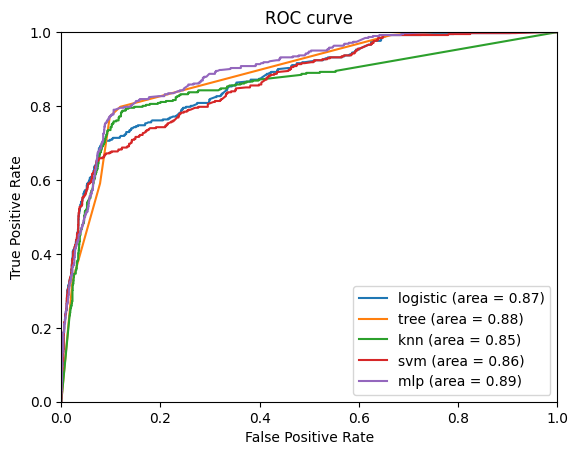

In [429]:
roc_curve_plot({"logistic" : logistic, "tree" : tree, "knn" : knn, "svm" : svm, "mlp" : mlp}, X_validation, y_validation)

In [430]:
show_results(results_selected)

,f1,roc_auc,pr_auc,log_loss,training_time,prediction_time
Logistic Regression,0.632124,0.870631,0.643165,0.430600,0.149005,0.000002
Decision Tree,0.668942,0.882471,0.554240,0.345341,0.144003,0.000002
KNN,0.639659,0.853453,0.581525,1.373260,4.702007,0.000010
SVM,0.631854,0.863280,0.632486,0.426819,0.195995,0.000003
MLP,0.668187,0.894566,0.659502,0.382314,2.551475,0.000003


## Model Performance Comparison

| Model                  | F1     | ROC AUC | PR AUC | Log Loss | Train Time | Pred Time |
|------------------------|--------|---------|--------|----------|------------|-----------|
| Logistic Regression    | 0.6321 | 0.8706  | 0.6432 | 0.4306   | 0.156      | 0.000002  |
| Decision Tree          | 0.6689 | 0.8825  | 0.5542 | 0.3453   | 0.156      | 0.000002  |
| KNN                    | 0.6563 | 0.8685  | 0.6097 | 0.7508   | 6.418      | 0.000111  |
| SVM                    | 0.6674 | 0.8684  | 0.4855 | 0.3849   | 34.537     | 0.000520  |
| MLP                    | 0.6674 | 0.8968  | 0.6633 | 0.3407   | 12.818     | 0.000006  |
| Ensemble Majority Vote | 0.6697 | 0.8981  | 0.6626 | 0.3454   | 52.845     | 0.000379  |
| Ensemble Stacking      | 0.6431 | 0.8955  | 0.6703 | 0.2629   | 186.304    | 0.000379  |

### Grid Search with modelling selected features

It was already run , but if u run it first , dont forget

In [ ]:
# models = {"Logistic Regression" : logistic_regression_pipeline(), "Decision Tree" : decision_tree_pipeline(), "K-Nearest Neighbors" : knn_pipeline(), "SVM" : svm_pipeline(), "MLP" : mlp_pipeline()} 

# params = {
#     "Logistic Regression": {
#         "lr__penalty": ["l2"],
#         "lr__C": [0.001, 0.01, 0.1, 1, 10, 100],
#         "lr__solver": ["lbfgs", "liblinear"],
#         "lr__max_iter": [1000],
#         "feature_selection__k": [3, 4, 5, 6]
#     },

#     "Decision Tree": {
#         "dt__criterion": ["gini", "entropy"],
#         "dt__max_depth": [None, 3, 5, 10, 20, 30],
#         "dt__min_samples_split": [2, 5, 10],
#         "dt__min_samples_leaf": [1, 2, 5],
#         "feature_selection__k": [3, 4, 5, 6]
#     },

#     "K-Nearest Neighbors": {
#         "knn__n_neighbors": [3, 5, 7, 11, 17, 27],
#         "knn__weights": ["uniform", "distance"],
#         "knn__p": [1, 2],
#         "feature_selection__k": [3, 4, 5, 6]
#     },

#     "SVM": {
#         # "svm__kernel": ["rbf", "sigmoid"],
#         # "svm__C": [0.01, 0.1, 1, 10],
#         # "svm__gamma": ["scale", "auto", 0.01, 0.1, 1.0],
#         # "feature_selection__k": [3, 4, 5, 6]
#         "svm__kernel": ["rbf"],  # quick + usually better here
        
#         "svm__C": [1, 10],  # quick
        
#         "svm__gamma": ["scale", 0.1]  # quick
#     },


#     "MLP": {
#         # # Width/depth controls representation capacity.
#         # "mlp__hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32), (256, 128, 64)],
#         # # L2 regularization strength for overfitting control.
#         # "mlp__alpha": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3],
#         # # Initial learning rate for Adam optimizer.
#         # "mlp__learning_rate_init": [3e-4, 5e-4, 1e-3, 2e-3],
#         # # Batch size can affect both convergence stability and generalization.
#         # "mlp__batch_size": [64, 128, 256],
#         "mlp__hidden_layer_sizes": [(64,32), (128,64)],
#         #"mlp__hidden_layer_sizes": [(64,32)],
#         "mlp__alpha": [1e-4, 1e-3],
#         "mlp__learning_rate_init": [5e-4, 1e-3],
#         "mlp__batch_size": [64,128],
#         "mlp__max_iter": [200, 500],
#         "feature_selection__k": [3, 4, 5, 6]
#     }
# }

# N_SPLITS = 5
# N_JOBS = min(4, os.cpu_count() or 1)
# cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# for model in models:
#     print(f"Running GridSearch for {model}")
#     grid_search = GridSearchCV(
#         estimator=models[model],
#         param_grid=params[model],
#         cv=cv,
#         n_jobs=N_JOBS,
#         pre_dispatch=N_JOBS,
#         scoring="f1",
#         verbose=2,
#         error_score=np.nan
#     )
#     grid_search.fit(X_train, y_train)

#     best_params_baseline[model] = grid_search.best_params_
#     best_scores_baseline[model] = grid_search.best_score_
#     best_models_baseline[model] = grid_search.best_estimator_

#     print("Best parameters:", grid_search.best_params_)
#     print("Best score:", grid_search.best_score_, "\n")

**Model Evaluation & GridSearch Results (Iteration 2)**

| Rank | Model | Best CV Score | Fits | Optimal Parameters |
| :--- | :--- | :--- | :--- | :--- |
| **1** | **Decision Tree** | **0.6874** | 2160 | `k: 3`, `criterion: 'gini'`, `max_depth: 3`, `min_samples_leaf: 1`, `min_samples_split: 2` |
| **2** | **MLP** | 0.6868 | 640 | `k: 3`, `alpha: 0.001`, `batch_size: 64`, `hidden_layer_sizes: (128, 64)`, `learning_rate_init: 0.001`, `max_iter: 500` |
| 3** | **SVM** | 0.6763 | 20 | `C: 1`, `gamma: 'scale'`, `kernel: 'rbf'` *(Note: Severely constrained grid)* |
| **4** | **K-Nearest Neighbors**| 0.6734 | 480 | `k: 3`, `n_neighbors: 27`, `p: 1`, `weights: 'uniform'` |
| **5** | **Logistic Regression**| 0.6631 | 240 | `k: 3`, `C: 1`, `max_iter: 1000`, `penalty: 'l2'`, `solver: 'liblinear'` |

### Ensemble - Majority Vote

In [431]:
from sklearn.ensemble import VotingClassifier
from sklearn.utils.validation import check_is_fitted

class HardVotingClassifierWithProba(VotingClassifier):
    def __init__(self, estimators):
        super().__init__(estimators=estimators, voting="hard")

    def predict_proba(self, X):
        check_is_fitted(self)
        probas = np.asarray([est.predict_proba(X) for est in self.estimators_])
        return np.mean(probas, axis=0)


In [432]:
# majority vote ensemble
ensemble = HardVotingClassifierWithProba(
    estimators=[
        ("lr", logistic_regression_pipeline()),
        ("dt", decision_tree_pipeline()),
        ("knn", knn_pipeline()),
        ("svm", svm_pipeline()),
        ("mlp", mlp_pipeline())
    ]
)

y_predicted, y_proba, train_time, prediction_time = run_model(
    ensemble, X_train, y_train, X_validation, y_validation
)

results_selected["Ensemble Majority Vote"] = compute_metrics(
    y_validation, y_predicted, train_time, prediction_time, y_proba
)

display(pd.DataFrame(results_selected).T.loc[["Ensemble Majority Vote"]])


Training time: 7.79s
Time spent making 1 prediction: 0.000027s

F1 score: 0.671
ROC-AUC: 0.893
PR-AUC: 0.659
Log Loss: 0.353 

Confusion Matrix: 
 [[1894  191]
 [  92  289]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.95      0.91      0.93      2085
        True       0.60      0.76      0.67       381

    accuracy                           0.89      2466
   macro avg       0.78      0.83      0.80      2466
weighted avg       0.90      0.89      0.89      2466



,f1,roc_auc,pr_auc,log_loss,training_time,prediction_time
Ensemble Majority Vote,0.671312,0.892661,0.658643,0.352609,7.794659,0.000027


### Ensemble - Stacking

In [433]:
stack = StackingClassifier(
    estimators=[
        ("lr", logistic_regression_pipeline()),
        ("dt", decision_tree_pipeline()),
        ("knn", knn_pipeline()),
        ("svm", svm_pipeline()),
        ("mlp", mlp_pipeline())
    ],
    final_estimator=LogisticRegression(C=1, max_iter=1000, penalty="l2", solver="liblinear"),
    cv=5
)

y_predicted, y_proba, train_time, prediction_time = run_model(stack, X_train, y_train, X_validation, y_validation)

results_selected["Ensemble Stacking"] = compute_metrics(y_validation, y_predicted, train_time, prediction_time, y_proba)

Training time: 39.52s
Time spent making 1 prediction: 0.000020s

F1 score: 0.638
ROC-AUC: 0.893
PR-AUC: 0.656
Log Loss: 0.264 

Confusion Matrix: 
 [[1941  144]
 [ 135  246]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.93      0.93      0.93      2085
        True       0.63      0.65      0.64       381

    accuracy                           0.89      2466
   macro avg       0.78      0.79      0.79      2466
weighted avg       0.89      0.89      0.89      2466



In [434]:
show_results(results_selected)

,f1,roc_auc,pr_auc,log_loss,training_time,prediction_time
Logistic Regression,0.632124,0.870631,0.643165,0.430600,0.149005,0.000002
Decision Tree,0.668942,0.882471,0.554240,0.345341,0.144003,0.000002
KNN,0.639659,0.853453,0.581525,1.373260,4.702007,0.000010
SVM,0.631854,0.863280,0.632486,0.426819,0.195995,0.000003
MLP,0.668187,0.894566,0.659502,0.382314,2.551475,0.000003
Ensemble Majority Vote,0.671312,0.892661,0.658643,0.352609,7.794659,0.000027
Ensemble Stacking,0.638132,0.893277,0.656253,0.263652,39.517055,0.000020


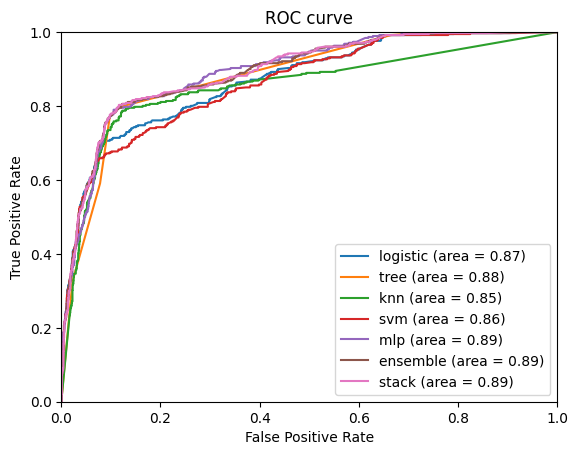

In [435]:
roc_curve_plot({"logistic" : logistic, "tree" : tree, "knn" : knn, "svm" : svm, "mlp" : mlp, "ensemble" : ensemble, "stack" : stack}, X_validation, y_validation)

In [436]:
estimators = stack.named_estimators_

# loop through each model and print selected features
for model_name, pipeline in estimators.items():
    var_filter = pipeline.named_steps.get("variance_check")
    selector = pipeline.named_steps.get("feature_selection")

    input_features = var_filter.get_support()
    remaining_features = X_train.columns[input_features]
    
    selected_mask = selector.get_support()
    selected_features = remaining_features[selected_mask]
    
    print(f"{model_name} selected features:")
    print(list(selected_features))

lr selected features:
['ExitRates', 'PageValues', 'Month_May']
dt selected features:
['ExitRates', 'PageValues', 'Month_May']
knn selected features:
['BounceRates', 'ExitRates', 'PageValues']
svm selected features:
['ExitRates', 'PageValues', 'Month_May']
mlp selected features:
['ExitRates', 'PageValues', 'Month_May']


## Genetic Ensemble Feature Selection (GEFS)

### GEFS Core
This block defines the GEFS estimator used by both homogeneous and heterogeneous experiments.
Run this once before any GEFS experiments.

In [ ]:
#FINAL GEFS
from scipy.stats import mode

from sklearn.base import BaseEstimator, clone
from sklearn.feature_selection import f_classif
from sklearn.metrics import f1_score, average_precision_score
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted


class SubsetClassifier(BaseEstimator):
    def __init__(self, model, features):
        self.model = model
        self.features = features

    def fit(self, X, y):
        self.model_ = clone(self.model)
        self.model_.fit(X[:, self.features == 1], y)
        if hasattr(self.model_, "classes_"):
            self.classes_ = self.model_.classes_
        self.fitted_ = True
        return self

    def predict(self, X):
        return self.model_.predict(X[:, self.features == 1])

    def predict_proba(self, X):
        return self.model_.predict_proba(X[:, self.features == 1])


class genetic_ensemble_feature_selection(BaseEstimator):
    def __init__(
        self,
        base_estimators,
        ensemble=False,
        init_lambda=0.45,
        population_size=5,
        num_generations=10,
        max_features=3,
        smart_feature_pool=True,
        feature_pool_size=20,
        validation_size=0.20,
        selection_random_state=42,
    ):
        self.base_estimator = list(base_estimators.values())
        self.model_names = list(base_estimators.keys())
        self.ensemble = ensemble
        self.init_lambda = init_lambda
        self.population_size = population_size
        self.num_generations = num_generations
        self.max_features = max_features
        self.smart_feature_pool = smart_feature_pool
        self.feature_pool_size = feature_pool_size
        self.validation_size = validation_size
        self.selection_random_state = selection_random_state

    def fit(self, X, y):
        np.random.seed(self.selection_random_state)

        if hasattr(X, "values"):
            X = X.values
        if hasattr(y, "values"):
            y = y.values

        X = np.asarray(X)
        y = np.asarray(y)

        num_features = X.shape[1]
        self.lam = self.init_lambda

        X_fit, X_eval, y_fit, y_eval = self._make_selection_split(X, y)

        if self.smart_feature_pool:
            try:
                scores, _ = f_classif(X_fit, y_fit)
                scores = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)
            except Exception:
                scores = np.ones(num_features)

            self.feature_scores_ = scores
            pool_size = min(self.feature_pool_size, num_features)
            self.allowed_features_ = np.argsort(scores)[::-1][:pool_size]
        else:
            self.feature_scores_ = np.ones(num_features)
            self.allowed_features_ = np.arange(num_features)

        self.population = np.array([
            self.cap_features(self.random_mask(num_features), num_features)
            for _ in range(self.population_size)
        ])
        self.model_types = np.array([i % len(self.base_estimator) for i in range(self.population_size)])
        self.models = self.train(X_fit, y_fit, self.population, self.model_types)

        fitness = np.ones(self.population_size, dtype=float)

        for _ in range(self.num_generations):
            new_population, new_model_types = self.mutate(
                self.population, self.model_types, num_features, fitness
            )
            new_models = self.train(X_fit, y_fit, new_population, new_model_types)

            total_population = np.vstack((self.population, new_population))
            total_model_types = np.concatenate((self.model_types, new_model_types))
            total_models = self.models + new_models

            fitness = self.score_population(X_eval, y_eval, total_population, total_models)

            fit_df = pd.DataFrame({
                "fitness": fitness,
                "population": list(total_population),
                "model_types": total_model_types,
                "model": total_models,
            }).sort_values("fitness", ascending=False)

            if len(self.base_estimator) > 1 and self.ensemble is False:
                best_idx = self._select_majority_survivors(fit_df)
            elif len(self.base_estimator) > 1 and self.ensemble == "stacking":
                best_idx = self._select_stacking_survivors(fit_df)
            else:
                best_idx = self._select_homo_survivors(fit_df)

            if not best_idx:
                raise RuntimeError("GEFS survivor selection produced no candidates.")

            fit_df = fit_df.loc[best_idx[:self.population_size]]

            self.population = np.vstack(fit_df["population"].values)
            self.model_types = fit_df["model_types"].values
            self.models = self.train(X_fit, y_fit, self.population, self.model_types)

            fitness = np.asarray(fit_df["fitness"].values, dtype=float)
            self.lam *= 0.96

        self.models = self.train(X, y, self.population, self.model_types)

        if self.ensemble == "stacking":
            estimators = [
                (f"{self.model_names[mt]}_{i}", model)
                for i, (mt, model) in enumerate(zip(self.model_types, self.models))
            ]

            self.stacking_model = StackingClassifier(
                estimators=estimators,
                final_estimator=LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    solver="liblinear",
                    class_weight=None,
                    max_iter=1000,
                    random_state=self.selection_random_state,
                ),
                cv=3,
                stack_method="predict_proba",
                passthrough=False,
            )
            self.stacking_model.fit(X, y)

        self.is_fitted_ = True
        return self

    def _make_selection_split(self, X, y):
        unique_classes, counts = np.unique(y, return_counts=True)
        if len(unique_classes) < 2 or np.min(counts) < 2:
            return X, X, y, y

        try:
            return train_test_split(
                X,
                y,
                test_size=self.validation_size,
                random_state=self.selection_random_state,
                stratify=y,
            )
        except Exception:
            return X, X, y, y

    def _positive_proba(self, model, X):
        proba = model.predict_proba(X)

        if proba.ndim == 1:
            return proba

        if proba.shape[1] == 1:
            classes = getattr(model, "classes_", np.array([0]))
            return np.ones(X.shape[0]) if classes[0] == 1 else np.zeros(X.shape[0])

        classes = getattr(model, "classes_", np.arange(proba.shape[1]))
        if 1 in classes:
            pos_idx = int(np.where(classes == 1)[0][0])
            return proba[:, pos_idx]

        return proba[:, -1]

    def _mask_key(self, mask):
        return tuple(np.asarray(mask, dtype=int).tolist())

    def _mask_novelty_scores(self, populations):
        novelties = []
        pop_sets = [set(np.where(mask == 1)[0]) for mask in populations]

        for i, s_i in enumerate(pop_sets):
            overlaps = []
            for j, s_j in enumerate(pop_sets):
                if i == j:
                    continue
                union = len(s_i | s_j)
                sim = 1.0 if union == 0 else len(s_i & s_j) / union
                overlaps.append(sim)

            novelties.append(1.0 - np.mean(overlaps) if overlaps else 1.0)

        return np.asarray(novelties, dtype=float)

    def score_population(self, X_eval, y_eval, populations, models):
        y_preds = np.array([m.predict(X_eval) for m in models]).astype(int)
        y_probs = np.array([self._positive_proba(m, X_eval) for m in models])

        f1s = np.array([
            f1_score(y_eval, yp, zero_division=0)
            for yp in y_preds
        ])
        pr_aucs = np.array([
            average_precision_score(y_eval, yp)
            for yp in y_probs
        ])
        divs = np.array([
            np.mean(y_preds[i] != np.delete(y_preds, i, axis=0))
            for i in range(len(y_preds))
        ])
        novelties = self._mask_novelty_scores(populations)

        norm_f1 = self.normalize(f1s)
        norm_pr = self.normalize(pr_aucs)
        norm_div = self.normalize(divs)
        norm_novelty = self.normalize(novelties)

        mask_quality = np.array([
            np.mean(self.feature_scores_[np.where(mask == 1)[0]]) if np.any(mask) else 0.0
            for mask in populations
        ])
        norm_mask_q = self.normalize(mask_quality)

        if len(self.base_estimator) > 1:
            return (
                0.68 * norm_f1
                + 0.16 * norm_pr
                + 0.08 * norm_novelty
                + 0.05 * norm_mask_q
                + self.lam * norm_div
            )

        return (
            0.78 * norm_f1
            + 0.14 * norm_pr
            + 0.08 * norm_novelty
            + self.lam * norm_div
        )

    def _backfill_distinct(self, fit_df, best_idx, seen_masks, type_counts=None, max_per_type=None):
        if len(best_idx) >= self.population_size:
            return best_idx[:self.population_size]

        for idx, row in fit_df.iterrows():
            if idx in best_idx:
                continue

            mask_key = self._mask_key(row["population"])
            if mask_key in seen_masks:
                continue

            if type_counts is not None and max_per_type is not None:
                model_type = int(row["model_types"])
                if type_counts.get(model_type, 0) >= max_per_type:
                    continue
                type_counts[model_type] = type_counts.get(model_type, 0) + 1

            best_idx.append(idx)
            seen_masks.add(mask_key)

            if len(best_idx) == self.population_size:
                break

        return best_idx[:self.population_size]

    def _select_majority_survivors(self, fit_df):
        best_idx = []
        seen_masks = set()

        for model_type in range(len(self.base_estimator)):
            group = fit_df[fit_df["model_types"] == model_type]
            if group.empty:
                continue

            chosen_idx = None
            for idx, row in group.iterrows():
                mask_key = self._mask_key(row["population"])
                if mask_key not in seen_masks:
                    chosen_idx = idx
                    seen_masks.add(mask_key)
                    break

            if chosen_idx is None:
                chosen_idx = group.index[0]
                seen_masks.add(self._mask_key(group.loc[chosen_idx, "population"]))

            best_idx.append(chosen_idx)

        return self._backfill_distinct(fit_df, best_idx, seen_masks)

    def _select_stacking_survivors(self, fit_df):
        best_idx = []
        seen_masks = set()
        type_counts = {i: 0 for i in range(len(self.base_estimator))}
        max_per_type = 2

        for model_type in range(len(self.base_estimator)):
            group = fit_df[fit_df["model_types"] == model_type]
            if group.empty:
                continue

            chosen_idx = None
            for idx, row in group.iterrows():
                mask_key = self._mask_key(row["population"])
                if mask_key not in seen_masks:
                    chosen_idx = idx
                    seen_masks.add(mask_key)
                    type_counts[model_type] += 1
                    break

            if chosen_idx is None:
                chosen_idx = group.index[0]
                seen_masks.add(self._mask_key(group.loc[chosen_idx, "population"]))
                type_counts[model_type] += 1

            best_idx.append(chosen_idx)

        best_idx = self._backfill_distinct(
            fit_df, best_idx, seen_masks, type_counts=type_counts, max_per_type=max_per_type
        )

        linear_types = []
        for i, name in enumerate(self.model_names):
            if name.upper() in {"LR", "SVM"}:
                linear_types.append(i)

        selected_types = set(int(fit_df.loc[idx, "model_types"]) for idx in best_idx)
        has_linear = any(t in selected_types for t in linear_types)

        if linear_types and not has_linear:
            candidate_idx = None
            for idx, row in fit_df.iterrows():
                model_type = int(row["model_types"])
                if model_type not in linear_types:
                    continue
                mask_key = self._mask_key(row["population"])
                if mask_key in seen_masks:
                    continue
                candidate_idx = idx
                break

            if candidate_idx is not None:
                duplicate_candidates = [
                    idx for idx in best_idx
                    if type_counts[int(fit_df.loc[idx, "model_types"])] > 1
                ]
                if duplicate_candidates:
                    weakest_duplicate = min(
                        duplicate_candidates,
                        key=lambda j: float(fit_df.loc[j, "fitness"])
                    )
                    best_idx.remove(weakest_duplicate)
                    best_idx.append(candidate_idx)

        return best_idx[:self.population_size]

    def _select_homo_survivors(self, fit_df):
        best_idx = []
        seen_masks = set()

        for idx, row in fit_df.iterrows():
            mask_key = self._mask_key(row["population"])
            if mask_key in seen_masks:
                continue

            best_idx.append(idx)
            seen_masks.add(mask_key)

            if len(best_idx) == self.population_size:
                break

        return best_idx

    def train(self, X, y, population, types):
        return [
            SubsetClassifier(self.base_estimator[t], p).fit(X, y)
            for p, t in zip(population, types)
        ]

    def predict(self, X):
        if hasattr(X, "values"):
            X = X.values

        check_is_fitted(self, "is_fitted_")

        if self.ensemble == "stacking":
            return self.stacking_model.predict(X)

        preds = np.asarray([m.predict(X) for m in self.models]).astype(np.int64)
        return mode(preds, axis=0, keepdims=True).mode.ravel()

    def predict_proba(self, X):
        if hasattr(X, "values"):
            X = X.values

        check_is_fitted(self, "is_fitted_")

        if self.ensemble == "stacking":
            return self.stacking_model.predict_proba(X)

        return np.mean([m.predict_proba(X) for m in self.models], axis=0)

    def cap_features(self, mask, n):
        if hasattr(self, "allowed_features_"):
            allowed_mask = np.zeros(n, dtype=bool)
            allowed_mask[self.allowed_features_] = True
            mask = mask.copy()
            mask[~allowed_mask] = 0

        if np.sum(mask) > self.max_features:
            ones = np.where(mask == 1)[0]
            scores = np.clip(self.feature_scores_[ones], 0, None) ** 1.0
            s = np.sum(scores)
            probs = (scores / s) if s > 0 else None
            keep = np.random.choice(ones, self.max_features, replace=False, p=probs)
            mask[:] = 0
            mask[keep] = 1

        while np.sum(mask) < 2:
            avail = np.where(mask == 0)[0]
            if hasattr(self, "allowed_features_"):
                avail = np.intersect1d(avail, self.allowed_features_)
            if len(avail) == 0:
                break
            mask[np.random.choice(avail)] = 1

        return mask

    def random_mask(self, n):
        mask = np.zeros(n, dtype=int)
        allowed = self.allowed_features_
        k = np.random.randint(2, self.max_features + 1)

        weights = np.clip(self.feature_scores_[allowed], 0, None) ** 1.0
        s = np.sum(weights)
        probs = (weights / s) if s > 0 else None

        chosen = np.random.choice(
            allowed,
            size=min(k, len(allowed)),
            replace=False,
            p=probs
        )
        mask[chosen] = 1
        return mask

    def mutate(self, p, t, n, f):
        new_p = []
        new_t = []

        s = np.sum(f)
        probs = (f / s) if s > 0 else None

        for _ in range(self.population_size):
            idx1, idx2 = np.random.choice(
                len(p),
                2,
                replace=(len(p) < 2),
                p=probs if len(p) >= 2 else None
            )

            child = np.where(np.random.randint(2, size=n), p[idx1], p[idx2])

            if np.random.rand() < 0.22:
                child = np.where(np.random.rand(n) < 0.15, 1 - child, child)

            child_type = t[idx1] if np.random.rand() < 0.55 else t[idx2]

            if np.random.rand() < 0.12:
                child_type = np.random.randint(len(self.base_estimator))

            new_p.append(self.cap_features(child, n))
            new_t.append(child_type)

        return np.array(new_p), np.array(new_t)

    def normalize(self, s):
        s = np.asarray(s, dtype=float)
        mi, ma = s.min(), s.max()
        return np.ones(len(s)) if mi == ma else (s - mi) / (ma - mi)

### GEFS Configuration
Use these toggles to control runtime and behavior (smart pool on/off, SVM on/off, k, population, generations, lambda).
All GEFS blocks below read from this single config.

In [ ]:
# GEFS master toggles (single source of truth)  # changed
USE_SVM = True  # changed

GEFS_MAX_FEATURES = 3  # changed
GEFS_POPULATION_SIZE = 5  # changed
GEFS_NUM_GENERATIONS = 8  # changed
GEFS_INIT_LAMBDA = 0.50  # changed

GEFS_SMART_FEATURE_POOL = True  # changed
GEFS_FEATURE_POOL_SIZE = 20  # changed

### GEFS Shared Helpers
These helper functions avoid repeated code and keep experiments trackable.
They build base models, run homogeneous/heterogeneous GEFS, and print member-feature assignments.

In [461]:
# Shared helpers for GEFS experiments
if "results_gefs" not in globals():
    results_gefs = {}


def build_gefs_base_models(use_svm=USE_SVM):
    models = {
        "LR": LogisticRegression(
            C=1,
            max_iter=1000,
            penalty="l2",
            solver="liblinear"
        ),
        "DT": DecisionTreeClassifier(
            criterion="gini",
            max_depth=3,
            min_samples_leaf=1,
            min_samples_split=2,
            random_state=42
        ),
        "KNN": KNeighborsClassifier(
            n_neighbors=15,
            p=1,
            weights="distance"
        ),
        "MLP": MLPClassifier(
            alpha=0.001,
            batch_size=128,
            hidden_layer_sizes=(64, 32),
            learning_rate_init=0.0005,
            max_iter=500,
            random_state=42
        ),
        # "MLP": MLPClassifier(
        #     alpha=0.001,
        #     batch_size=128,
        #     hidden_layer_sizes=(64, 32),
        #     learning_rate_init=0.0005,
        #     max_iter=300,
        #     early_stopping=True,
        #     n_iter_no_change=10,
        #     random_state=42 ),
        
    }

    if use_svm:
        base_svm = LinearSVC(C=1, dual=False, max_iter=10000, random_state=42)
        models["SVM"] = CalibratedClassifierCV(base_svm, method="isotonic", cv=3)

    return models


def run_homo_gefs(model_key, model, label, ensemble_mode=False):
    gefs = genetic_ensemble_feature_selection(
        {model_key: model},
        ensemble=("stacking" if ensemble_mode else False),
        max_features=GEFS_MAX_FEATURES,
        population_size=GEFS_POPULATION_SIZE,
        num_generations=GEFS_NUM_GENERATIONS,
        init_lambda=GEFS_INIT_LAMBDA,
        smart_feature_pool=GEFS_SMART_FEATURE_POOL,
        feature_pool_size=GEFS_FEATURE_POOL_SIZE,
    )

    step_name = f"gefs_homo_{model_key.lower()}_{'stack' if ensemble_mode else 'maj'}"
    pipe = Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("variance_check", VarianceThreshold()),
        ("scalar", StandardScaler()),
        (step_name, gefs),
    ])

    y_pred, y_proba, train_time, prediction_time = run_model(
        pipe, X_train, y_train, X_validation, y_validation
    )
    results_gefs[label] = compute_metrics(y_validation, y_pred, train_time, prediction_time, y_proba)
    return pipe


def run_hetero_gefs(label, ensemble_mode=False):
    gefs = genetic_ensemble_feature_selection(
        build_gefs_base_models(USE_SVM),
        ensemble=("stacking" if ensemble_mode else False),
        max_features=GEFS_MAX_FEATURES,
        population_size=GEFS_POPULATION_SIZE,
        num_generations=GEFS_NUM_GENERATIONS,
        init_lambda=GEFS_INIT_LAMBDA,
        smart_feature_pool=GEFS_SMART_FEATURE_POOL,
        feature_pool_size=GEFS_FEATURE_POOL_SIZE,
    )

    step_name = "gefs_ensemble_stacking" if ensemble_mode else "gefs_ensemble_majority"
    pipe = Pipeline([
        ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
        ("variance_check", VarianceThreshold()),
        ("scalar", StandardScaler()),
        (step_name, gefs),
    ])

    y_pred, y_proba, train_time, prediction_time = run_model(
        pipe, X_train, y_train, X_validation, y_validation
    )
    results_gefs[label] = compute_metrics(y_validation, y_pred, train_time, prediction_time, y_proba)
    return pipe


def print_gefs_member_features(name, pipe):
    gefs_step = None
    for step in pipe.named_steps.values():
        if (
            step.__class__.__name__ == "genetic_ensemble_feature_selection"
            or (hasattr(step, "population") and hasattr(step, "model_types") and hasattr(step, "model_names"))
        ):
            gefs_step = step
            break

    if gefs_step is None:
        print(f"{name}: no GEFS step found")
        return

    vt = pipe.named_steps["variance_check"]
    feats = np.array(X_train.columns)[vt.get_support()]

    print(f"\n{name} members and selected features:")
    for i, mask in enumerate(gefs_step.population):
        model_idx = int(gefs_step.model_types[i])
        model_name = gefs_step.model_names[model_idx]
        used = feats[mask.astype(bool)]
        print(f" Member {i+1} ({model_name}, {int(mask.sum())} features): {list(used)}")

    if GEFS_SMART_FEATURE_POOL and hasattr(gefs_step, "allowed_features_"):
        ranked_idx = np.array(gefs_step.allowed_features_, dtype=int)
        ranked_scores = np.array(gefs_step.feature_scores_)[ranked_idx]
        ranked_feats = feats[ranked_idx]
        ranked_df = (
            pd.DataFrame({"feature": ranked_feats, "score": ranked_scores})
            .sort_values("score", ascending=False)
            .head(12)
        )
        print(" Top smart-pool features:")
        print(ranked_df.to_string(index=False))


### Homogeneous GEFS - Logistic Regression
Single-model-family GEFS run for LR.

In [442]:
lr_gefs = run_homo_gefs(
    "LR",
    LogisticRegression(C=1, max_iter=1000, penalty="l2", solver="liblinear"),
    "LR-GEFS",
    ensemble_mode=False
)

Training time: 1.34s
Time spent making 1 prediction: 0.000054s

F1 score: 0.652
ROC-AUC: 0.889
PR-AUC: 0.660
Log Loss: 0.427 

Confusion Matrix: 
 [[1935  150]
 [ 124  257]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.94      0.93      0.93      2085
        True       0.63      0.67      0.65       381

    accuracy                           0.89      2466
   macro avg       0.79      0.80      0.79      2466
weighted avg       0.89      0.89      0.89      2466



### Homogeneous GEFS - Decision Tree
Single-model-family GEFS run for DT.

In [443]:
dt_gefs = run_homo_gefs(
    "DT",
    DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=1, min_samples_split=2),
    "DT-GEFS",
    ensemble_mode=False
)


Training time: 1.12s
Time spent making 1 prediction: 0.000054s

F1 score: 0.656
ROC-AUC: 0.900
PR-AUC: 0.675
Log Loss: 0.342 

Confusion Matrix: 
 [[1843  242]
 [  77  304]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.96      0.88      0.92      2085
        True       0.56      0.80      0.66       381

    accuracy                           0.87      2466
   macro avg       0.76      0.84      0.79      2466
weighted avg       0.90      0.87      0.88      2466



### Homogeneous GEFS - KNN
Single-model-family GEFS run for KNN.

In [444]:
knn_gefs = run_homo_gefs(
    "KNN",
    KNeighborsClassifier(n_neighbors=15, p=1, weights="distance"),
    "KNN-GEFS",
    ensemble_mode=False
)

Training time: 8.91s
Time spent making 1 prediction: 0.000177s

F1 score: 0.662
ROC-AUC: 0.886
PR-AUC: 0.633
Log Loss: 0.370 

Confusion Matrix: 
 [[1857  228]
 [  80  301]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.96      0.89      0.92      2085
        True       0.57      0.79      0.66       381

    accuracy                           0.88      2466
   macro avg       0.76      0.84      0.79      2466
weighted avg       0.90      0.88      0.88      2466



### Homogeneous GEFS - SVM (Optional)
Runs only when `USE_SVM=True` to control runtime.

In [ ]:
_old_gen = GEFS_NUM_GENERATIONS
GEFS_NUM_GENERATIONS = 12  # Deep search to find the best 3-feature subset

try:
    if USE_SVM:

        base_svm = LinearSVC(
            C=1.0, 
            loss='squared_hinge', 
            dual=False, 
            max_iter=10000, 
            tol=1e-4, 
            random_state=42
        )
        
        
        svm_model = CalibratedClassifierCV(base_svm, method='isotonic', cv=3)
        
        svm_gefs = run_homo_gefs(
            "SVM",
            svm_model,
            "SVM-GEFS",
            ensemble_mode=False
        )
    else:
        svm_gefs = None
        print("Skipping SVM-GEFS (USE_SVM=False)")
finally:
    GEFS_NUM_GENERATIONS = _old_gen


Training time: 4.70s
Time spent making 1 prediction: 0.000058s

F1 score: 0.663
ROC-AUC: 0.896
PR-AUC: 0.655
Log Loss: 0.336 

Confusion Matrix: 
 [[1859  226]
 [  80  301]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.96      0.89      0.92      2085
        True       0.57      0.79      0.66       381

    accuracy                           0.88      2466
   macro avg       0.76      0.84      0.79      2466
weighted avg       0.90      0.88      0.88      2466



Training time: 1202.98s
Time spent making 1 prediction: 0.002331s

F1 score: 0.661
ROC-AUC: 0.881
PR-AUC: 0.506
Log Loss: 0.376 

Confusion Matrix: 
 [[1886  199]
 [  95  286]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.95      0.90      0.93      2085
        True       0.59      0.75      0.66       381

    accuracy                           0.88      2466
   macro avg       0.77      0.83      0.79      2466
weighted avg       0.90      0.88      0.89      2466


Training time: 1947.66s
Time spent making 1 prediction: 0.001771s

F1 score: 0.667
ROC-AUC: 0.868
PR-AUC: 0.485
Log Loss: 0.381 

Confusion Matrix: 
 [[1887  198]
 [  91  290]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.95      0.91      0.93      2085
        True       0.59      0.76      0.67       381

    accuracy                           0.88      2466
   macro avg       0.77      0.83      0.80      2466
weighted avg       0.90      0.88      0.89      2466

In [446]:
print([v for v in ["lr_gefs","dt_gefs","knn_gefs","mlp_gefs","svm_gefs","majority_gefs","stacking_gefs"] if v in globals() and globals()[v] is not None])


['lr_gefs', 'dt_gefs', 'knn_gefs', 'mlp_gefs', 'svm_gefs', 'majority_gefs', 'stacking_gefs']


### Homogeneous GEFS - MLP
Single-model-family GEFS run for MLP.

In [447]:
mlp_gefs = run_homo_gefs(
    "MLP",
    MLPClassifier(hidden_layer_sizes=(64, 32),
    alpha=1e-3,
    learning_rate_init=5e-4,
    batch_size=128,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1,
    random_state=42),
    "MLP-GEFS",
    ensemble_mode=False
)


Training time: 166.67s
Time spent making 1 prediction: 0.000058s

F1 score: 0.663
ROC-AUC: 0.905
PR-AUC: 0.688
Log Loss: 0.363 

Confusion Matrix: 
 [[1879  206]
 [  90  291]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.95      0.90      0.93      2085
        True       0.59      0.76      0.66       381

    accuracy                           0.88      2466
   macro avg       0.77      0.83      0.79      2466
weighted avg       0.90      0.88      0.89      2466



Training time: 124.67s
Time spent making 1 prediction: 0.000077s

F1 score: 0.668
ROC-AUC: 0.895
PR-AUC: 0.660
Log Loss: 0.382 

Confusion Matrix: 
 [[1882  203]
 [  88  293]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.96      0.90      0.93      2085
        True       0.59      0.77      0.67       381

    accuracy                           0.88      2466
   macro avg       0.77      0.84      0.80      2466
weighted avg       0.90      0.88      0.89      2466

Training time: 540.94s
Time spent making 1 prediction: 0.000077s

F1 score: 0.667
ROC-AUC: 0.903
PR-AUC: 0.655
Log Loss: 0.357 

Confusion Matrix: 
 [[1881  204]
 [  88  293]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.96      0.90      0.93      2085
        True       0.59      0.77      0.67       381

    accuracy                           0.88      2466
   macro avg       0.77      0.84      0.80      2466
weighted avg       0.90      0.88      0.89      2466

### Heterogeneous GEFS - Majority Vote
Mixed-model GEFS ensemble combined by majority voting.

In [451]:
majority_gefs = run_hetero_gefs("Majority-GEFS", ensemble_mode=False)

Training time: 142.71s
Time spent making 1 prediction: 0.000134s

F1 score: 0.667
ROC-AUC: 0.919
PR-AUC: 0.696
Log Loss: 0.319 

Confusion Matrix: 
 [[1883  202]
 [  89  292]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.95      0.90      0.93      2085
        True       0.59      0.77      0.67       381

    accuracy                           0.88      2466
   macro avg       0.77      0.83      0.80      2466
weighted avg       0.90      0.88      0.89      2466



### Heterogeneous GEFS - Stacking
Mixed-model GEFS ensemble combined by stacking.

In [450]:
stacking_gefs = run_hetero_gefs("Stacking-GEFS", ensemble_mode=True)


Training time: 171.44s
Time spent making 1 prediction: 0.000042s

F1 score: 0.670
ROC-AUC: 0.920
PR-AUC: 0.694
Log Loss: 0.332 

Confusion Matrix: 
 [[1885  200]
 [  88  293]] 

Performance Metrics: 
               precision    recall  f1-score   support

       False       0.96      0.90      0.93      2085
        True       0.59      0.77      0.67       381

    accuracy                           0.88      2466
   macro avg       0.77      0.84      0.80      2466
weighted avg       0.90      0.88      0.89      2466



### GEFS Outputs
This block prints summary metrics and member-feature assignments for all GEFS runs.

,f1,roc_auc,pr_auc,log_loss,training_time,prediction_time
LR-GEFS,0.652284,0.889056,0.659843,0.427021,1.344997,0.000054
DT-GEFS,0.655879,0.900463,0.674758,0.341703,1.123997,0.000054
KNN-GEFS,0.661538,0.885799,0.632606,0.370050,8.905990,0.000177
SVM-GEFS,0.662996,0.896324,0.655034,0.336483,4.703466,0.000058
MLP-GEFS,0.662870,0.905041,0.688092,0.363223,166.668393,0.000058



LR-GEFS members and selected features:
 Member 1 (LR, 3 features): ['PageValues', 'Weekend', 'Month_Mar']
 Member 2 (LR, 3 features): ['PageValues', 'Month_May', 'TrafficType_1']
 Member 3 (LR, 3 features): ['ExitRates', 'PageValues', 'Month_May']
 Member 4 (LR, 3 features): ['PageValues', 'Weekend', 'Browser_1']
 Member 5 (LR, 3 features): ['ExitRates', 'PageValues', 'Region_3']
 Top smart-pool features:
                      feature       score
                   PageValues 2986.744264
                    ExitRates 1394.681934
                    Month_May  861.441130
           OperatingSystems_3  759.730176
                  BounceRates  754.597542
                TrafficType_3  747.774399
VisitorType_Returning_Visitor  679.787405
                TrafficType_1  673.551812
                    Month_Mar  598.540475
           OperatingSystems_1  473.047515
                     Region_3  470.602465
                    Browser_1  441.566811

DT-GEFS members and selected features:
 Mem

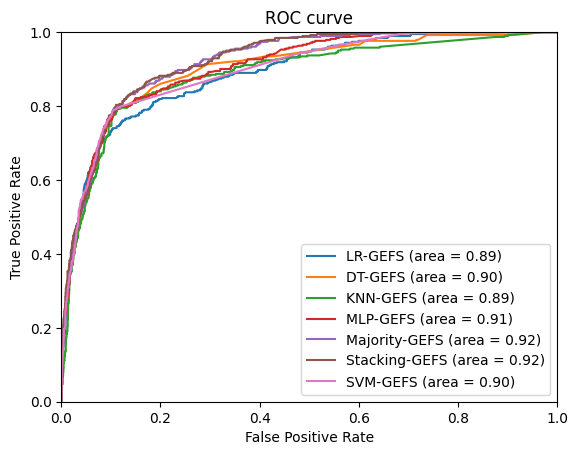

In [ ]:
show_results(results_gefs)

fitted_gefs = {
    "LR-GEFS": lr_gefs,
    "DT-GEFS": dt_gefs,
    "KNN-GEFS": knn_gefs,
    "MLP-GEFS": mlp_gefs,
    "Majority-GEFS": majority_gefs,
    "Stacking-GEFS": stacking_gefs,
}
if USE_SVM and svm_gefs is not None:
    fitted_gefs["SVM-GEFS"] = svm_gefs

for name, pipe in fitted_gefs.items():
    print_gefs_member_features(name, pipe)

plot_models = {
    "LR-GEFS": lr_gefs,
    "DT-GEFS": dt_gefs,
    "KNN-GEFS": knn_gefs,
    "MLP-GEFS": mlp_gefs,
    "Majority-GEFS": majority_gefs,
    "Stacking-GEFS": stacking_gefs,
}
if USE_SVM and svm_gefs is not None:
    plot_models["SVM-GEFS"] = svm_gefs

roc_curve_plot(plot_models, X_validation, y_validation)


### Temp Experiments (Optional)
These cells are preserved for exploratory checks. They are not required for the main GEFS run path.

In [ ]:
# TEMP: Smart feature-pool inspection (self-contained)

import numpy as np
import pandas as pd
import warnings
from sklearn.feature_selection import f_classif, VarianceThreshold
from sklearn.model_selection import train_test_split
from IPython.display import display

# Fallbacks to ensure X_train/y_train exist
if "X_train" not in globals() or "y_train" not in globals():
    if "X" in globals() and "y" in globals():
        X_train, _, y_train, _ = train_test_split(
            X, y, test_size=0.4, random_state=42, stratify=y
        )
    elif "online_shoppers" in globals():
        X = online_shoppers.drop(columns=["Revenue"])
        y = online_shoppers["Revenue"]
        X_train, _, y_train, _ = train_test_split(
            X, y, test_size=0.4, random_state=42, stratify=y
        )
    else:
        online_shoppers = pd.read_csv("../data/online_shoppers_updated.csv")
        X = online_shoppers.drop(columns=["Revenue"])
        y = online_shoppers["Revenue"]
        X_train, _, y_train, _ = train_test_split(
            X, y, test_size=0.4, random_state=42, stratify=y
        )

if "GEFS_FEATURE_POOL_SIZE" not in globals():
    GEFS_FEATURE_POOL_SIZE = 20

# Match GEFS input space (variance filtering first)
vt_pool = VarianceThreshold()
X_pool_values = vt_pool.fit_transform(X_train)
y_pool_values = y_train.values if hasattr(y_train, "values") else y_train
feature_names = np.array(X_train.columns)[vt_pool.get_support()]

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Features .* are constant.")
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    scores, p_values = f_classif(X_pool_values, y_pool_values)

scores = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)

ranked_idx = np.argsort(scores)[::-1]
top_k = min(GEFS_FEATURE_POOL_SIZE, len(ranked_idx))
top_idx = ranked_idx[:top_k]

df_pool = pd.DataFrame({
    "feature": feature_names[top_idx],
    "f_score": scores[top_idx],
    "p_value": p_values[top_idx]
})

max_score = df_pool["f_score"].max() if len(df_pool) else 1.0
df_pool["norm_score_0_1"] = (df_pool["f_score"] / max_score) if max_score > 0 else 0.0
df_pool["percentile_rank"] = df_pool["f_score"].rank(pct=True, method="average")
df_pool["grade"] = pd.cut(
    df_pool["percentile_rank"],
    bins=[0.0, 0.50, 0.75, 0.90, 1.00],
    labels=["D", "C", "B", "A"],
    include_lowest=True
)

print(f"Smart pool size: {top_k}")
print("Ranking basis: ANOVA f_classif on training split after variance filtering.")
display(df_pool.sort_values("f_score", ascending=False).reset_index(drop=True))

print("Allowed feature indices (variance-filtered space):")
print(top_idx.tolist())
print("Allowed feature names:")
print(df_pool.sort_values("f_score", ascending=False)["feature"].tolist())


Smart pool size: 20
Ranking basis: ANOVA f_classif on training split after variance filtering.


,feature,f_score,p_value,norm_score_0_1,percentile_rank,grade
0,PageValues,2449.004962,0.000000e+00,1.000000,1.00,A
1,ExitRates,338.839240,5.047218e-74,0.138358,0.95,A
2,ProductRelated,198.629827,1.561703e-44,0.081106,0.90,B
3,BounceRates,170.850775,1.289199e-38,0.069763,0.85,B
4,Month_Nov,170.520382,1.516532e-38,0.069628,0.80,B
5,ProductRelated_Duration,157.538432,9.021975e-36,0.064328,0.75,C
6,Administrative,137.471023,1.804262e-31,0.056133,0.70,C
7,TrafficType_2,120.852959,6.760979e-28,0.049348,0.65,C
8,VisitorType_New_Visitor,76.419917,2.804264e-18,0.031204,0.60,C
9,VisitorType_Returning_Visitor,72.274916,2.241918e-17,0.029512,0.55,C


Allowed feature indices (variance-filtered space):
[8, 7, 4, 6, 19, 5, 0, 55, 21, 23, 1, 9, 2, 56, 13, 54, 12, 25, 26, 66]
Allowed feature names:
['PageValues', 'ExitRates', 'ProductRelated', 'BounceRates', 'Month_Nov', 'ProductRelated_Duration', 'Administrative', 'TrafficType_2', 'VisitorType_New_Visitor', 'VisitorType_Returning_Visitor', 'Administrative_Duration', 'SpecialDay', 'Informational', 'TrafficType_3', 'Month_May', 'TrafficType_1', 'Month_Mar', 'OperatingSystems_2', 'OperatingSystems_3', 'TrafficType_13']


In [ ]:
# # TEMP: smart-pool True vs False after random-capping fix  # changed
# # Uses updated GEFS capping: smart_pool=False now matches old random trimming.  # changed

# import pandas as pd  # changed
# from imblearn.pipeline import Pipeline  # changed
# from imblearn.over_sampling import SMOTE  # changed
# from sklearn.preprocessing import StandardScaler  # changed
# from sklearn.feature_selection import VarianceThreshold  # changed
# from sklearn.linear_model import LogisticRegression  # changed
# from sklearn.tree import DecisionTreeClassifier  # changed
# from sklearn.neighbors import KNeighborsClassifier  # changed
# from sklearn.neural_network import MLPClassifier  # changed
# from sklearn.svm import SVC  # changed
# from scipy.stats import mode as scipy_mode  # changed
# mode = scipy_mode  # changed

# required = ["X_train", "y_train", "X_validation", "y_validation", "run_model", "compute_metrics", "genetic_ensemble_feature_selection"]  # changed
# missing = [v for v in required if v not in globals()]  # changed
# if missing:  # changed
#     raise RuntimeError(f"Missing required objects: {missing}")  # changed

# USE_SVM_TEMP = False  # changed
# FIXED_K = 3  # changed
# FIXED_POP = 5  # changed
# FIXED_GEN = 8  # changed
# FIXED_LAMBDA = 0.4  # changed
# FIXED_POOL_SIZE = 20  # changed
# SMART_VALUES = [False, True]  # changed

# def _base_models_temp():  # changed
#     models = {
#         "LR": LogisticRegression(C=1, max_iter=1000, penalty="l2", solver="liblinear"),
#         "DT": DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=1, min_samples_split=2),
#         "KNN": KNeighborsClassifier(n_neighbors=27, p=1, weights="uniform"),
#         "MLP": MLPClassifier(alpha=0.001, batch_size=64, hidden_layer_sizes=(64, 32), learning_rate_init=0.0005, max_iter=500),
#     }
#     if USE_SVM_TEMP:
#         models["SVM"] = SVC(C=10, gamma=1.0, kernel="rbf", probability=True)
#     return models

# def _build_gefs(ens_mode, smart_flag):  # changed
#     gefs = genetic_ensemble_feature_selection(
#         _base_models_temp(),
#         ensemble=("stacking" if ens_mode == "stacking" else False),
#         max_features=FIXED_K,
#         population_size=FIXED_POP,
#         num_generations=FIXED_GEN,
#         init_lambda=FIXED_LAMBDA,
#         smart_feature_pool=smart_flag,
#         feature_pool_size=FIXED_POOL_SIZE
#     )
#     step_name = "gefs_ensemble_stacking_smart_fix" if ens_mode == "stacking" else "gefs_ensemble_maj_vote_smart_fix"
#     return Pipeline([
#         ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
#         ("variance_check", VarianceThreshold()),
#         ("scalar", StandardScaler()),
#         (step_name, gefs)
#     ])

# rows = []  # changed
# for smart_flag in SMART_VALUES:  # changed
#     for ens_mode in ["majority", "stacking"]:  # changed
#         print(f"Running ensemble={ens_mode}, smart_pool={smart_flag}")  # changed
#         pipe = _build_gefs(ens_mode, smart_flag)  # changed
#         y_pred, y_proba, tr_t, pr_t = run_model(pipe, X_train, y_train, X_validation, y_validation)  # changed
#         m = compute_metrics(y_validation, y_pred, tr_t, pr_t, y_proba)  # changed
#         m["model"] = f"{ens_mode.title()} GEFS (smart_pool={smart_flag}, random-cap-fix)"  # changed
#         m["smart_pool"] = smart_flag  # changed
#         m["ensemble_type"] = ens_mode  # changed
#         rows.append(m)  # changed

# df_smart_compare_fix = pd.DataFrame(rows).set_index("model")  # changed
# display(df_smart_compare_fix[["smart_pool", "ensemble_type", "f1", "roc_auc", "pr_auc", "log_loss", "training_time", "prediction_time"]]
#         .sort_values(["ensemble_type", "pr_auc"], ascending=[True, False]))  # changed

# print("\nBest by PR-AUC:")  # changed
# display(df_smart_compare_fix.sort_values("pr_auc", ascending=False).head(1))  # changed


In [ ]:
# # TEMP: smart-pool True vs False (gen=10, random-cap-fix)  # changed
# # Same setup as previous smart-pool test, only generations changed to 10.  # changed

# import pandas as pd  # changed
# from imblearn.pipeline import Pipeline  # changed
# from imblearn.over_sampling import SMOTE  # changed
# from sklearn.preprocessing import StandardScaler  # changed
# from sklearn.feature_selection import VarianceThreshold  # changed
# from sklearn.linear_model import LogisticRegression  # changed
# from sklearn.tree import DecisionTreeClassifier  # changed
# from sklearn.neighbors import KNeighborsClassifier  # changed
# from sklearn.neural_network import MLPClassifier  # changed
# from sklearn.svm import SVC  # changed
# from scipy.stats import mode as scipy_mode  # changed
# mode = scipy_mode  # changed

# required = ["X_train", "y_train", "X_validation", "y_validation", "run_model", "compute_metrics", "genetic_ensemble_feature_selection"]  # changed
# missing = [v for v in required if v not in globals()]  # changed
# if missing:  # changed
#     raise RuntimeError(f"Missing required objects: {missing}")  # changed

# USE_SVM_TEMP = False  # changed
# FIXED_K = 3  # changed
# FIXED_POP = 5  # changed
# FIXED_GEN = 10  # changed
# FIXED_LAMBDA = 0.4  # changed
# FIXED_POOL_SIZE = 20  # changed
# SMART_VALUES = [False, True]  # changed

# def _base_models_temp_gen10():  # changed
#     models = {
#         "LR": LogisticRegression(C=1, max_iter=1000, penalty="l2", solver="liblinear"),
#         "DT": DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=1, min_samples_split=2),
#         "KNN": KNeighborsClassifier(n_neighbors=27, p=1, weights="uniform"),
#         "MLP": MLPClassifier(alpha=0.001, batch_size=64, hidden_layer_sizes=(64, 32), learning_rate_init=0.0005, max_iter=500),
#     }
#     if USE_SVM_TEMP:
#         models["SVM"] = SVC(C=10, gamma=1.0, kernel="rbf", probability=True)
#     return models

# def _build_gefs_gen10(ens_mode, smart_flag):  # changed
#     gefs = genetic_ensemble_feature_selection(
#         _base_models_temp_gen10(),
#         ensemble=("stacking" if ens_mode == "stacking" else False),
#         max_features=FIXED_K,
#         population_size=FIXED_POP,
#         num_generations=FIXED_GEN,
#         init_lambda=FIXED_LAMBDA,
#         smart_feature_pool=smart_flag,
#         feature_pool_size=FIXED_POOL_SIZE
#     )
#     step_name = "gefs_ensemble_stacking_smart_fix_gen10" if ens_mode == "stacking" else "gefs_ensemble_maj_vote_smart_fix_gen10"
#     return Pipeline([
#         ("smote", SMOTE(random_state=42, sampling_strategy="minority")),
#         ("variance_check", VarianceThreshold()),
#         ("scalar", StandardScaler()),
#         (step_name, gefs)
#     ])

# rows_gen10 = []  # changed
# for smart_flag in SMART_VALUES:  # changed
#     for ens_mode in ["majority", "stacking"]:  # changed
#         print(f"Running ensemble={ens_mode}, smart_pool={smart_flag}, gen=10")  # changed
#         pipe = _build_gefs_gen10(ens_mode, smart_flag)  # changed
#         y_pred, y_proba, tr_t, pr_t = run_model(pipe, X_train, y_train, X_validation, y_validation)  # changed
#         m = compute_metrics(y_validation, y_pred, tr_t, pr_t, y_proba)  # changed
#         m["model"] = f"{ens_mode.title()} GEFS (smart_pool={smart_flag}, gen=10)"  # changed
#         m["smart_pool"] = smart_flag  # changed
#         m["ensemble_type"] = ens_mode  # changed
#         rows_gen10.append(m)  # changed

# df_smart_compare_gen10 = pd.DataFrame(rows_gen10).set_index("model")  # changed
# display(df_smart_compare_gen10[["smart_pool", "ensemble_type", "f1", "roc_auc", "pr_auc", "log_loss", "training_time", "prediction_time"]]
#         .sort_values(["ensemble_type", "pr_auc"], ascending=[True, False]))  # changed

# print("\nBest by PR-AUC (gen=10):")  # changed
# display(df_smart_compare_gen10.sort_values("pr_auc", ascending=False).head(1))  # changed


| model | smart_pool | ensemble_type | f1 | roc_auc | pr_auc | log_loss | training_time | prediction_time |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| Majority GEFS (smart_pool=True, gen=10) | True | majority | 0.667426 | 0.894304 | 0.647972 | 0.329377 | 120.871885 | 0.000153 |
| Majority GEFS (smart_pool=False, gen=10) | False | majority | 0.659341 | 0.882835 | 0.597797 | 0.360278 | 152.578214 | 0.000195 |
| Stacking GEFS (smart_pool=True, gen=10) | True | stacking | 0.668942 | 0.894305 | 0.649720 | 0.349613 | 197.633592 | 0.000052 |
| Stacking GEFS (smart_pool=False, gen=10) | False | stacking | 0.668182 | 0.886982 | 0.599331 | 0.344287 | 199.721880 | 0.000042 |


| Best by PR-AUC (gen=10) | f1 | roc_auc | pr_auc | log_loss | training_time | prediction_time | smart_pool | ensemble_type |
|---|---:|---:|---:|---:|---:|---:|---|---|
| Stacking GEFS (smart_pool=True, gen=10) | 0.668942 | 0.894305 | 0.649720 | 0.349613 | 197.633592 | 0.000052 | True | stacking |


### SVM-GEFS C Sweep Results

| C | F1 | PR-AUC | ROC-AUC | Log Loss | Training Time (s) | Prediction Time (s/sample) |
|---:|---:|---:|---:|---:|---:|---:|
| 1  | 0.661922 | 0.529807 | 0.867282 | 0.380118 | 1295.474911 | 0.002353 |
| 5  | 0.659674 | 0.541262 | 0.880356 | 0.371590 | 1221.462322 | 0.002256 |
| 10 | 0.655699 | 0.541489 | 0.870179 | 0.373893 | 1353.414421 | 0.002073 |


In [ ]:
print([v for v in ["lr_gefs","dt_gefs","knn_gefs","mlp_gefs","majority_gefs","stacking_gefs","svm_gefs"] if v in globals()])


['lr_gefs', 'dt_gefs', 'knn_gefs', 'mlp_gefs', 'majority_gefs', 'stacking_gefs', 'svm_gefs']


### Frozen Setup (No More Tuning)
- Final GEFS config for reporting:
  - `USE_SVM = True`
  - `GEFS_MAX_FEATURES = 3`
  - `GEFS_POPULATION_SIZE = 5`
  - `GEFS_NUM_GENERATIONS = 8`
  - `GEFS_INIT_LAMBDA = 0.5`
  - `GEFS_SMART_FEATURE_POOL = True`
  - `GEFS_FEATURE_POOL_SIZE = 20`
- SVM-only experiment override:
  - `exp_num_generations = 6` in `SVM-GEFS` cell only.
  - `svm models , c=5 `
- Freeze rule:
  - No more tuning changes for main result tables and statistical evaluation.


## Final Evaluation and Statistical Testing
This block is the final, report-facing evaluation protocol.
It assumes tuning is finished and compares only frozen model configurations.


In [ ]:
# Quick freeze check
print(USE_SVM, GEFS_MAX_FEATURES, GEFS_POPULATION_SIZE, GEFS_NUM_GENERATIONS, GEFS_INIT_LAMBDA, GEFS_SMART_FEATURE_POOL, GEFS_FEATURE_POOL_SIZE)
print(sorted(results_gefs.keys()))


True 3 5 8 0.5 True 20
['DT-GEFS', 'KNN-GEFS', 'LR-GEFS', 'MLP-GEFS', 'Majority-GEFS', 'SVM-GEFS', 'Stacking-GEFS']


### A) Final Model Selection and Main Results (Merged A+B)

This section performs the full final comparison in one place:

1. Automatically selects the **best single baseline** using **validation F1** (primary metric).
2. Compares exactly three final models on the held-out test set:
   - Best Single Baseline
   - Majority-GEFS
   - Stacking-GEFS
3. Produces the final main-results table (Table 1) with:
   - F1 (primary)
   - PR-AUC
   - ROC-AUC
   - Log Loss
   - Training Time
   - Prediction Time

No tuning is performed in this block.


| Model | F1 | ROC-AUC | PR-AUC | Log Loss | Training Time (s) | Prediction Time (s/sample) |
|---|---:|---:|---:|---:|---:|---:|
| **Best Single Baseline (Logistic Regression)** | 0.518771 | 0.889093 | 0.623500 | **0.295479** | **0.160030** | **0.000004** |
| **Majority-GEFS** | 0.656000 | **0.901370** | **0.638100** | 0.339755 | 308.948775 | 0.000512 |
| **Stacking-GEFS** | **0.664399** | 0.894937 | 0.631134 | 0.348353 | 462.272938 | 0.000399 |

In [ ]:
# A1) Auto-select best single baseline (validation F1) + build final Table 1 on test
# Merged functionality from old A and B blocks.
# --- Preconditions ---
required = [
    "results_selected", "results_gefs",
    "compute_metrics", "show_results",
    "X_test", "y_test",
    "logistic", "tree", "knn", "svm", "mlp",
    "majority_gefs", "stacking_gefs"
]

missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

# --- 1) Choose best single baseline by VALIDATION F1 (single models only) ---
single_names = ["Logistic Regression", "Decision Tree", "KNN", "SVM", "MLP"]
val_single_df = pd.DataFrame(results_selected).T.loc[single_names]
best_single_name_raw = val_single_df["f1"].idxmax()

name_to_model_obj = {
    "Logistic Regression": logistic,
    "Decision Tree": tree,
    "KNN": knn,
    "SVM": svm,
    "MLP": mlp
}
best_single_model = name_to_model_obj[best_single_name_raw]
best_single_label = f"Best Single Baseline ({best_single_name_raw})"

print(f"[Selection] Best single baseline by validation F1: {best_single_name_raw}")

# --- 2) Final model set ---
final_models = {
    best_single_label: best_single_model,
    "Majority-GEFS": majority_gefs,
    "Stacking-GEFS": stacking_gefs
}

# --- 3) Evaluate on held-out TEST (NO-REFIT; fast) ---
# Note: this uses already-fitted objects in memory.
results_final = {}
pred_store = {}

for label, model in final_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # timing NaN here by design (no-refit evaluation)
    results_final[label] = compute_metrics(y_test, y_pred, np.nan, np.nan, y_proba)

    # store for bootstrap/statistical comparison
    pred_store[label] = {
        "y_pred": np.asarray(y_pred),
        "y_proba": np.asarray(y_proba)
    }

# --- 4) Attach runtime from prior train+evaluate runs for Table 1 ---
runtime_map = {
    best_single_label: ("results_selected", best_single_name_raw),
    "Majority-GEFS": ("results_gefs", "Majority-GEFS"),
    "Stacking-GEFS": ("results_gefs", "Stacking-GEFS"),
}

table1 = pd.DataFrame(results_final).T[["f1", "pr_auc", "roc_auc", "log_loss"]].copy()

for row_label, (src_name, key) in runtime_map.items():
    src = results_selected if src_name == "results_selected" else results_gefs
    if key not in src:
        raise RuntimeError(f"Runtime source missing: {src_name}['{key}']")
    table1.loc[row_label, "training_time"] = src[key]["training_time"]
    table1.loc[row_label, "prediction_time"] = src[key]["prediction_time"]

table1 = table1[["f1", "pr_auc", "roc_auc", "log_loss", "training_time", "prediction_time"]]

print("\nFinal Main Results (Table 1):")

# Optional: quick sorted view by F1 (primary)
display(table1.sort_values("f1", ascending=False))


[Selection] Best single baseline by validation F1: Decision Tree

Final Main Results (Table 1):


,f1,pr_auc,roc_auc,log_loss,training_time,prediction_time
Best Single Baseline (Decision Tree),0.664399,0.537709,0.883213,0.349856,0.138823,0.000002
Majority-GEFS,0.663647,0.683910,0.918067,0.323110,161.324784,0.000094
Stacking-GEFS,0.662085,0.687631,0.920246,0.337787,168.744855,0.000042


f1	pr_auc	roc_auc	log_loss	training_time	prediction_time
Best Single Baseline (Decision Tree)	0.664399	0.537709	0.883213	0.349856	0.138823	0.000002
Stacking-GEFS	0.663647	0.622855	0.896707	0.353085	166.877444	0.000015
Majority-GEFS	0.653722	0.650269	0.901607	0.337913	102.464047	0.000091


	f1	pr_auc	roc_auc	log_loss	training_time	prediction_time
Best Single Baseline (Decision Tree)	0.664399	0.537709	0.883213	0.349856	0.138823	0.000002
Stacking-GEFS	0.660613	0.644242	0.901518	0.340836	121.260814	0.000024
Majority-GEFS	0.649945	0.668476	0.907343	0.337052	67.721134	0.000067


### B) Bootstrap 95% Confidence Intervals (Pairwise Deltas)
Estimate uncertainty of model differences on held-out test predictions.

Report at least:

- Stacking - Best Single: ΔPR-AUC, ΔF1 (95% CI)
- Majority - Best Single: ΔPR-AUC, ΔF1 (95% CI)
- Stacking - Majority: ΔPR-AUC, ΔF1 (95% CI)

This table feeds report **Table 2**.


In [392]:
# B1) Bootstrap 95% CI for pairwise deltas (Table 2)
# Aim: compute paired bootstrap 95% CI for delta metrics (PR-AUC, F1).
# Output should be a compact DataFrame ready for Table 2.
required = ["pred_store", "y_test"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

# Identify labels robustly from Section A output
all_labels = list(pred_store.keys())

best_candidates = [k for k in all_labels if k.startswith("Best Single Baseline")]
if len(best_candidates) != 1:
    raise RuntimeError(f"Could not uniquely identify Best Single label. Found: {best_candidates}")
best_label = best_candidates[0]

if "Majority-GEFS" not in pred_store or "Stacking-GEFS" not in pred_store:
    raise RuntimeError("pred_store must contain 'Majority-GEFS' and 'Stacking-GEFS'.")

y_true = np.asarray(y_test).astype(int)

def _pos_proba(y_proba):
    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 2 and y_proba.shape[1] >= 2:
        return y_proba[:, 1]
    return y_proba.ravel()

def bootstrap_delta(y_true, pred_a, proba_a, pred_b, proba_b, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    d_f1 = []
    d_pr = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb = y_true[idx]

        # skip degenerate bootstrap samples with one class only
        if np.unique(yb).size < 2:
            continue

        pa = pred_a[idx]
        pb = pred_b[idx]
        sa = proba_a[idx]
        sb = proba_b[idx]

        d_f1.append(f1_score(yb, pa, zero_division=0) - f1_score(yb, pb, zero_division=0))
        d_pr.append(average_precision_score(yb, sa) - average_precision_score(yb, sb))

    d_f1 = np.asarray(d_f1)
    d_pr = np.asarray(d_pr)

    return {
        "delta_f1": d_f1.mean(),
        "delta_f1_ci_low": np.percentile(d_f1, 2.5),
        "delta_f1_ci_high": np.percentile(d_f1, 97.5),
        "delta_pr_auc": d_pr.mean(),
        "delta_pr_auc_ci_low": np.percentile(d_pr, 2.5),
        "delta_pr_auc_ci_high": np.percentile(d_pr, 97.5),
        "n_boot_used": len(d_f1),
    }

comparisons = [
    ("Stacking - Best Single", "Stacking-GEFS", best_label),
    ("Majority - Best Single", "Majority-GEFS", best_label),
    ("Stacking - Majority", "Stacking-GEFS", "Majority-GEFS"),
]

rows = []
for comp_name, a_label, b_label in comparisons:
    pred_a = np.asarray(pred_store[a_label]["y_pred"]).astype(int)
    pred_b = np.asarray(pred_store[b_label]["y_pred"]).astype(int)
    proba_a = _pos_proba(pred_store[a_label]["y_proba"])
    proba_b = _pos_proba(pred_store[b_label]["y_proba"])

    out = bootstrap_delta(
        y_true, pred_a, proba_a, pred_b, proba_b,
        n_boot=2000, seed=42
    )
    out["comparison"] = comp_name
    rows.append(out)

df_boot = pd.DataFrame(rows).set_index("comparison")

# Compact report-ready formatting
table2 = pd.DataFrame(index=df_boot.index)
table2["ΔF1 (95% CI)"] = df_boot.apply(
    lambda r: f"{r['delta_f1']:.4f} [{r['delta_f1_ci_low']:.4f}, {r['delta_f1_ci_high']:.4f}]",
    axis=1
)
table2["ΔPR-AUC (95% CI)"] = df_boot.apply(
    lambda r: f"{r['delta_pr_auc']:.4f} [{r['delta_pr_auc_ci_low']:.4f}, {r['delta_pr_auc_ci_high']:.4f}]",
    axis=1
)
table2["n_boot"] = df_boot["n_boot_used"].astype(int)

print("Bootstrap Table 2:")
display(table2)


Bootstrap Table 2:


,ΔF1 (95% CI),ΔPR-AUC (95% CI),n_boot
comparison,,,
Stacking - Best Single,"-0.0024 [-0.0104, 0.0044]","0.1511 [0.1209, 0.1804]",2000
Majority - Best Single,"-0.0008 [-0.0074, 0.0057]","0.1465 [0.1193, 0.1738]",2000
Stacking - Majority,"-0.0016 [-0.0090, 0.0050]","0.0046 [-0.0060, 0.0150]",2000


### C) Significance Test on Repeated Scores
Use one named statistical test on repeated model scores (validation-based repeated runs).

- Preferred: ANOVA on repeated PR-AUC scores (plus post-hoc if needed)
- Robust alternative: Friedman/Wilcoxon if assumptions are weak

Note: `f_classif` ANOVA in preprocessing is not the same as model-comparison significance testing.


In [388]:
# C0-fast: create df_rep without retraining (bootstrap-resampled test F1)
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

required = ["pred_store", "y_test"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

all_labels = list(pred_store.keys())
best_label = [k for k in all_labels if k.startswith("Best Single Baseline")]
if len(best_label) != 1:
    raise RuntimeError(f"Could not identify best single label. Found: {best_label}")
best_label = best_label[0]

y_true = np.asarray(y_test).astype(int)
n = len(y_true)
rng = np.random.default_rng(42)

n_repeats = 30  # fast and enough for Friedman/Wilcoxon stability
rows = []

for i in range(n_repeats):
    idx = rng.integers(0, n, size=n)
    yb = y_true[idx]

    # skip degenerate all-one-class sample
    if np.unique(yb).size < 2:
        continue

    f1_best = f1_score(yb, np.asarray(pred_store[best_label]["y_pred"])[idx], zero_division=0)
    f1_maj = f1_score(yb, np.asarray(pred_store["Majority-GEFS"]["y_pred"])[idx], zero_division=0)
    f1_stk = f1_score(yb, np.asarray(pred_store["Stacking-GEFS"]["y_pred"])[idx], zero_division=0)

    rows.append({
        "seed": i + 1,
        "Best Single": f1_best,
        "Majority-GEFS": f1_maj,
        "Stacking-GEFS": f1_stk
    })

df_rep = pd.DataFrame(rows)
display(df_rep.head())
print(f"df_rep shape: {df_rep.shape}")


,seed,Best Single,Majority-GEFS,Stacking-GEFS
0,1,0.646720,0.642857,0.644783
1,2,0.694268,0.691410,0.689434
2,3,0.668213,0.664344,0.666667
3,4,0.677608,0.673709,0.676887
4,5,0.653552,0.648531,0.645374


df_rep shape: (30, 4)


### C2) Friedman Significance Test (Repeated F1)

We test whether repeated F1 scores differ across the three final models.

- **H0**: all models have equal repeated-score distributions.
- **H1**: at least one model differs.
- **Significance level**: \(\alpha = 0.05\)

Decision rule:
- If `p < 0.05`: statistically significant difference (reject H0).
- If `p >= 0.05`: no statistically significant difference (fail to reject H0).


In [ ]:
# C2) Friedman test only (no post-hoc yet)

from scipy.stats import friedmanchisquare
import numpy as np

required = ["df_rep"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError("df_rep is missing. Run C0-fast first.")

models = ["Best Single", "Majority-GEFS", "Stacking-GEFS"]
for m in models:
    if m not in df_rep.columns:
        raise RuntimeError(f"Missing column in df_rep: {m}")

alpha = 0.05
n = len(df_rep)
k = len(models)

chi2, p = friedmanchisquare(
    df_rep["Best Single"].values,
    df_rep["Majority-GEFS"].values,
    df_rep["Stacking-GEFS"].values
)

# Effect size for Friedman
kendalls_w = chi2 / (n * (k - 1))

print("Friedman test on repeated F1")
print(f"chi2 = {chi2:.4f}")
print(f"p-value = {p:.6f}")
print(f"Kendall's W = {kendalls_w:.4f}")
print(f"alpha = {alpha}")

if p < alpha:
    print("Result: SIGNIFICANT (reject H0). At least one model differs.")
else:
    print("Result: NOT significant (fail to reject H0). No clear difference detected.")


Friedman test on repeated F1
chi2 = 60.0000
p-value = 0.000000
Kendall's W = 1.0000
alpha = 0.05
Result: SIGNIFICANT (reject H0). At least one model differs.


**Interpretation (Friedman Test):**  
The Friedman test is a non-parametric significance test for repeated model scores.  
With \(p < 0.05\), we reject the null hypothesis that all models perform equally.  
Kendall’s \(W\) reports effect size (0=no agreement, 1=perfect rank agreement across repeats).  
Since the omnibus test is significant, we proceed with post-hoc pairwise comparisons.


### C2.2) Repeated-Measures ANOVA on Repeated F1 (Supplementary)

This ANOVA is for **model-score comparison** (not feature relevance ANOVA/f_classif).

- **H0**: mean repeated F1 is equal across models.
- **H1**: at least one model has different mean repeated F1.
- \(\alpha = 0.05\)

Note: this uses `df_rep` repeats; if `df_rep` came from bootstrap resampling (no retraining), treat as supplementary evidence.


In [ ]:
# C2A) Repeated-measures ANOVA on repeated F1 + pairwise post-hoc (paired t-test, Holm)

import pandas as pd
from itertools import combinations
from scipy.stats import ttest_rel
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

required = ["df_rep"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError("df_rep is missing. Run C0-fast first.")

models = ["Best Single", "Majority-GEFS", "Stacking-GEFS"]
for m in models:
    if m not in df_rep.columns:
        raise RuntimeError(f"Missing column in df_rep: {m}")

alpha = 0.05

# Long format for AnovaRM
anova_df = df_rep[["seed"] + models].melt(
    id_vars="seed", var_name="model", value_name="f1"
)

anova_res = AnovaRM(
    data=anova_df,
    depvar="f1",
    subject="seed",
    within=["model"]
).fit()

print("Repeated-measures ANOVA (within-subject factor: model)")
display(anova_res.anova_table)

p_anova = float(anova_res.anova_table.loc["model", "Pr > F"])
if p_anova < alpha:
    print(f"ANOVA result: SIGNIFICANT (p={p_anova:.6g} < {alpha})")
else:
    print(f"ANOVA result: NOT significant (p={p_anova:.6g} >= {alpha})")

# Post-hoc only if significant
if p_anova < alpha:
    rows = []
    for a, b in combinations(models, 2):
        stat, p_raw = ttest_rel(df_rep[a], df_rep[b])
        rows.append({
            "pair": f"{a} vs {b}",
            "t_stat": stat,
            "p_raw": p_raw,
            "mean_diff_(A-B)": float((df_rep[a] - df_rep[b]).mean())
        })

    posthoc = pd.DataFrame(rows)
    reject, p_holm, _, _ = multipletests(posthoc["p_raw"], alpha=alpha, method="holm")
    posthoc["p_holm"] = p_holm
    posthoc["significant_0.05"] = reject

    print("\nPost-hoc paired t-tests (Holm-corrected):")
    display(posthoc.sort_values("p_holm"))
else:
    print("Skipping post-hoc tests because omnibus ANOVA is not significant.")


Repeated-measures ANOVA (within-subject factor: model)


,F Value,Num DF,Den DF,Pr > F
model,53.347939,2.0,58.0,7.171543e-14


ANOVA result: SIGNIFICANT (p=7.17154e-14 < 0.05)

Post-hoc paired t-tests (Holm-corrected):


,pair,t_stat,p_raw,mean_diff_(A-B),p_holm,significant_0.05
0,Best Single vs Majority-GEFS,7.303967,4.805565e-08,0.0065,1.441670e-07,True
2,Majority-GEFS vs Stacking-GEFS,-7.303967,4.805565e-08,-0.0065,1.441670e-07,True
1,Best Single vs Stacking-GEFS,NaN,NaN,0.0000,NaN,True


### D) Logistic Regression Interpretability Snapshot
Include a short interpretability section for LR baseline:

- Top coefficients / odds-ratio direction
- Brief practical interpretation


In [468]:
# D1) LR interpretability cell
# Aim: extract interpretable Logistic Regression feature effects for reporting
# without ever replacing real names with generic feature_0, feature_1, ...

import numpy as np
import pandas as pd

required = ["logistic", "X_train"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

if not hasattr(X_train, "columns"):
    raise RuntimeError("X_train must be a DataFrame with column names for interpretable LR output.")

pipe = logistic

# 1. Find fitted LR estimator with coefficients
clf = None
for step in pipe.named_steps.values():
    if hasattr(step, "coef_"):
        clf = step
        break

if clf is None:
    raise RuntimeError("Could not find a fitted classifier with coef_ inside `logistic`.")

# 2. Recover transformed feature names safely
feature_names = pd.Index(X_train.columns.astype(str))

for step_name, step in pipe.named_steps.items():
    if step is clf:
        break

    # Feature selectors such as VarianceThreshold / SelectKBest
    if hasattr(step, "get_support"):
        support = step.get_support()
        if len(support) != len(feature_names):
            raise RuntimeError(
                f"Feature support length mismatch at step '{step_name}': "
                f"{len(support)} vs {len(feature_names)}."
            )
        feature_names = feature_names[support]
        continue

    # Transformers that preserve/rename features
    if hasattr(step, "get_feature_names_out"):
        try:
            out_names = step.get_feature_names_out(feature_names)
        except Exception:
            try:
                out_names = step.get_feature_names_out()
            except Exception:
                out_names = None

        if out_names is not None:
            feature_names = pd.Index(np.asarray(out_names, dtype=str))
            continue

# 3. Sanity check against coefficient dimension
coef = np.ravel(clf.coef_)

if len(coef) != len(feature_names):
    raise RuntimeError(
        "Could not recover exact transformed feature names for Logistic Regression. "
        f"Coefficient length is {len(coef)} but recovered feature count is {len(feature_names)}."
    )

# 4. Build interpretability table
lr_interpret = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef),
    "odds_ratio": np.exp(coef),
    "direction": np.where(coef > 0, "positive", "negative"),
}).sort_values("abs_coefficient", ascending=False)

# Compact views for paper use
top_positive = (
    lr_interpret[lr_interpret["coefficient"] > 0]
    .sort_values("coefficient", ascending=False)
    .head(5)
    .copy()
)

top_negative = (
    lr_interpret[lr_interpret["coefficient"] < 0]
    .sort_values("coefficient", ascending=True)
    .head(5)
    .copy()
)

top_absolute = lr_interpret.head(10).copy()

print("Top positive Logistic Regression effects:")
display(top_positive[["feature", "coefficient", "odds_ratio"]])

print("Top negative Logistic Regression effects:")
display(top_negative[["feature", "coefficient", "odds_ratio"]])

print("Top absolute Logistic Regression effects:")
display(top_absolute[["feature", "coefficient", "odds_ratio", "direction"]])

# 5. LaTeX-ready compact table for the paper / appendix
lr_table = top_absolute[["feature", "coefficient", "odds_ratio", "direction"]].copy()
lr_table["coefficient"] = lr_table["coefficient"].map(lambda x: round(float(x), 4))
lr_table["odds_ratio"] = lr_table["odds_ratio"].map(lambda x: round(float(x), 4))

print("\nLaTeX-ready LR interpretability table:")
print(lr_table.to_latex(index=False, escape=False))


Top positive Logistic Regression effects:


,feature,coefficient,odds_ratio
1,PageValues,3.465765,32.000928


Top negative Logistic Regression effects:


,feature,coefficient,odds_ratio
0,ExitRates,-0.748003,0.473311
2,Month_May,-0.740896,0.476687


Top absolute Logistic Regression effects:


,feature,coefficient,odds_ratio,direction
1,PageValues,3.465765,32.000928,positive
0,ExitRates,-0.748003,0.473311,negative
2,Month_May,-0.740896,0.476687,negative



LaTeX-ready LR interpretability table:
\begin{tabular}{lrrl}
\toprule
feature & coefficient & odds_ratio & direction \\
\midrule
PageValues & 3.465800 & 32.000900 & positive \\
ExitRates & -0.748000 & 0.473300 & negative \\
Month_May & -0.740900 & 0.476700 & negative \\
\bottomrule
\end{tabular}



### E) Report-Ready Conclusion Prompts
Use final tables to answer:

1. Does diversity improve performance on this dataset?
2. Does stacking outperform simpler alternatives on PR-AUC?
3. Is the complexity (time cost) justified by gains?
4. What are key limitations and next-step experiments?


In [469]:
#E Conclusion-ready summary snapshot

required = ["phase1_baselines", "phase2_homo", "phase3_hetero", "table1", "bootstrap_table"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

print("Best single baseline (validation):")
display(phase1_baselines[["f1", "pr_auc", "roc_auc", "log_loss"]].head(1))

print("Best homogeneous GEFS (validation):")
display(phase2_homo[["Base F1", "Homo F1", "$\\Delta$F1", "Base PR", "Homo PR", "$\\Delta$PR"]].head(1))

print("Heterogeneous GEFS (validation):")
display(phase3_hetero[["F1", "PR-AUC", "ROC-AUC", "LogLoss"]])

print("Final held-out test results:")
display(table1[["f1", "pr_auc", "roc_auc", "log_loss"]].sort_values("f1", ascending=False))

print("Bootstrap confidence intervals:")
display(bootstrap_table)


Best single baseline (validation):


,f1,pr_auc,roc_auc,log_loss
Decision Tree,0.668942,0.55424,0.882471,0.345341


Best homogeneous GEFS (validation):


,Base F1,Homo F1,$\Delta$F1,Base PR,Homo PR,$\Delta$PR
Model Family,,,,,,
SVM,0.631854,0.662996,0.031142,0.632486,0.655034,0.022548


Heterogeneous GEFS (validation):


,F1,PR-AUC,ROC-AUC,LogLoss
GEFS Stacking,0.670481,0.693830,0.920073,0.332384
GEFS Majority Vote,0.667429,0.696058,0.918738,0.318931


Final held-out test results:


,f1,pr_auc,roc_auc,log_loss
Best Single Baseline (Decision Tree),0.664399,0.537709,0.883213,0.349856
Majority-GEFS,0.663647,0.683910,0.918067,0.323110
Stacking-GEFS,0.662085,0.687631,0.920246,0.337787


Bootstrap confidence intervals:


,Comparison,Delta_F1,F1_95CI,Delta_PR_AUC,PR_95CI
0,Stacking - Best Single,-0.002430,"[-0.0104, 0.0044]",0.151127,"[0.1209, 0.1804]"
1,Majority - Best Single,-0.000754,"[-0.0077, 0.0063]",0.146543,"[0.1188, 0.1729]"
2,Stacking - Majority,-0.001644,"[-0.0091, 0.0049]",0.004543,"[-0.0062, 0.0149]"


In [471]:
# Diversity snapshot for fitted GEFS models
# Uses the validation data transformed up to the GEFS step.

import numpy as np
import pandas as pd
from itertools import combinations

required = ["lr_gefs", "dt_gefs", "knn_gefs", "mlp_gefs", "majority_gefs", "stacking_gefs", "X_validation"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

if "svm_gefs" in globals() and svm_gefs is not None:
    model_dict = {
        "LR-GEFS": lr_gefs,
        "DT-GEFS": dt_gefs,
        "KNN-GEFS": knn_gefs,
        "SVM-GEFS": svm_gefs,
        "MLP-GEFS": mlp_gefs,
        "Majority-GEFS": majority_gefs,
        "Stacking-GEFS": stacking_gefs,
    }
else:
    model_dict = {
        "LR-GEFS": lr_gefs,
        "DT-GEFS": dt_gefs,
        "KNN-GEFS": knn_gefs,
        "MLP-GEFS": mlp_gefs,
        "Majority-GEFS": majority_gefs,
        "Stacking-GEFS": stacking_gefs,
    }

def get_gefs_step_name_and_obj(pipe):
    for name, step in pipe.named_steps.items():
        if hasattr(step, "models") and hasattr(step, "population"):
            return name, step
    return None, None

def transform_to_gefs_input(pipe, X):
    Xt = X
    gefs_name, _ = get_gefs_step_name_and_obj(pipe)
    if gefs_name is None:
        raise RuntimeError("Could not find GEFS step in pipeline.")

    for name, step in pipe.named_steps.items():
        if name == gefs_name:
            break
        if hasattr(step, "transform"):
            Xt = step.transform(Xt)
        elif name == "smote":
            # SMOTE is skipped at validation/test time in pipeline inference
            continue

    if hasattr(Xt, "values"):
        Xt = Xt.values

    return np.asarray(Xt)

rows = []

for name, pipe in model_dict.items():
    gefs_name, gefs = get_gefs_step_name_and_obj(pipe)
    if gefs is None:
        continue

    Xt_val = transform_to_gefs_input(pipe, X_validation)

    member_preds = np.array([m.predict(Xt_val) for m in gefs.models])

    pred_disagreement = []
    feat_jaccard = []

    for i, j in combinations(range(len(gefs.models)), 2):
        pred_disagreement.append(np.mean(member_preds[i] != member_preds[j]))

        mask_i = set(np.where(np.asarray(gefs.population[i]) == 1)[0])
        mask_j = set(np.where(np.asarray(gefs.population[j]) == 1)[0])
        union = len(mask_i | mask_j)
        jacc = 1.0 if union == 0 else len(mask_i & mask_j) / union
        feat_jaccard.append(jacc)

    rows.append({
        "Model": name,
        "Avg_Pred_Disagreement": np.mean(pred_disagreement) if pred_disagreement else np.nan,
        "Avg_Feature_Jaccard": np.mean(feat_jaccard) if feat_jaccard else np.nan,
    })

diversity_df = pd.DataFrame(rows).sort_values("Avg_Pred_Disagreement", ascending=False)
display(diversity_df)

diversity_df_rounded = diversity_df.copy()
for col in ["Avg_Pred_Disagreement", "Avg_Feature_Jaccard"]:
    diversity_df_rounded[col] = diversity_df_rounded[col].map(lambda x: round(float(x), 4))

display(diversity_df_rounded)
print(diversity_df_rounded.to_latex(index=False))


,Model,Avg_Pred_Disagreement,Avg_Feature_Jaccard
2,KNN-GEFS,0.047202,0.350000
5,Majority-GEFS,0.046715,0.351667
6,Stacking-GEFS,0.046715,0.351667
0,LR-GEFS,0.036983,0.290000
3,SVM-GEFS,0.029765,0.425000
4,MLP-GEFS,0.022060,0.380000
1,DT-GEFS,0.014680,0.303333


,Model,Avg_Pred_Disagreement,Avg_Feature_Jaccard
2,KNN-GEFS,0.0472,0.3500
5,Majority-GEFS,0.0467,0.3517
6,Stacking-GEFS,0.0467,0.3517
0,LR-GEFS,0.0370,0.2900
3,SVM-GEFS,0.0298,0.4250
4,MLP-GEFS,0.0221,0.3800
1,DT-GEFS,0.0147,0.3033


\begin{tabular}{lrr}
\toprule
Model & Avg_Pred_Disagreement & Avg_Feature_Jaccard \\
\midrule
KNN-GEFS & 0.047200 & 0.350000 \\
Majority-GEFS & 0.046700 & 0.351700 \\
Stacking-GEFS & 0.046700 & 0.351700 \\
LR-GEFS & 0.037000 & 0.290000 \\
SVM-GEFS & 0.029800 & 0.425000 \\
MLP-GEFS & 0.022100 & 0.380000 \\
DT-GEFS & 0.014700 & 0.303300 \\
\bottomrule
\end{tabular}



### 4.1 Phase 1: Baseline Optimization

This block summarizes the optimized **single-model baselines** used as the reference set for later GEFS comparison.  
Only the selected-feature single models are included here. Since **F1** is the primary metric in this study, the baselines are ranked by validation-set F1. Secondary metrics are reported to provide additional context on ranking quality, calibration, and computational cost.


In [ ]:
# 4.1) Phase 1 baseline table (selected-feature single models only)

required = ["results_selected", "pd"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

single_models = [
    "Logistic Regression",
    "Decision Tree",
    "KNN",
    "SVM",
    "MLP",
]

missing_models = [m for m in single_models if m not in results_selected]
if missing_models:
    raise RuntimeError(f"Missing selected-feature baseline results: {missing_models}")

phase1_baselines = (
    pd.DataFrame(results_selected).T
    .loc[single_models, ["f1", "pr_auc", "roc_auc", "log_loss", "training_time", "prediction_time"]]
    .sort_values(["f1", "pr_auc"], ascending=False)
)

print("Phase 1 - Optimized single-model baselines (validation set):")
display(phase1_baselines)

best_single_phase1 = phase1_baselines.index[0]
print(f"Best single baseline by validation F1: {best_single_phase1}")

# Optional: report-ready rounded copy
phase1_baselines_rounded = phase1_baselines.copy()
for col in ["f1", "pr_auc", "roc_auc", "log_loss"]:
    phase1_baselines_rounded[col] = phase1_baselines_rounded[col].map(lambda x: round(float(x), 6))
for col in ["training_time", "prediction_time"]:
    phase1_baselines_rounded[col] = phase1_baselines_rounded[col].map(lambda x: round(float(x), 6))

display(phase1_baselines_rounded)




Phase 1 - Optimized single-model baselines (validation set):


,f1,pr_auc,roc_auc,log_loss,training_time,prediction_time
Decision Tree,0.668942,0.554240,0.882471,0.345341,0.144003,0.000002
MLP,0.668187,0.659502,0.894566,0.382314,2.551475,0.000003
KNN,0.639659,0.581525,0.853453,1.373260,4.702007,0.000010
Logistic Regression,0.632124,0.643165,0.870631,0.430600,0.149005,0.000002
SVM,0.631854,0.632486,0.863280,0.426819,0.195995,0.000003


Best single baseline by validation F1: Decision Tree


,f1,pr_auc,roc_auc,log_loss,training_time,prediction_time
Decision Tree,0.668942,0.554240,0.882471,0.345341,0.144003,0.000002
MLP,0.668187,0.659502,0.894566,0.382314,2.551475,0.000003
KNN,0.639659,0.581525,0.853453,1.373260,4.702007,0.000010
Logistic Regression,0.632124,0.643165,0.870631,0.430600,0.149005,0.000002
SVM,0.631854,0.632486,0.863280,0.426819,0.195995,0.000003


\begin{tabular}{lrrrrrr}
\toprule
 & F1 & PR-AUC & ROC-AUC & LogLoss & Train(s) & Pred(s) \\
\midrule
Decision Tree & 0.668942 & 0.554240 & 0.882471 & 0.345341 & 0.144003 & 0.000002 \\
MLP & 0.668187 & 0.659502 & 0.894566 & 0.382314 & 2.551475 & 0.000003 \\
KNN & 0.639659 & 0.581525 & 0.853453 & 1.373260 & 4.702007 & 0.000010 \\
Logistic Regression & 0.632124 & 0.643165 & 0.870631 & 0.430600 & 0.149005 & 0.000002 \\
SVM & 0.631854 & 0.632486 & 0.863280 & 0.426819 & 0.195995 & 0.000003 \\
\bottomrule
\end{tabular}



### 4.2 Phase 2: Homogeneous GEFS

This block compares each homogeneous GEFS model against its corresponding optimized selected-feature baseline on the validation set. Since F1 is the primary metric in this study, the main focus is whether within-family feature diversity improves validation F1 relative to the single-model reference, while PR-AUC and runtime are used as secondary comparison criteria.


In [ ]:
# 4.2) Phase 2 homogeneous GEFS comparison (validation set)

required = ["results_selected", "results_gefs", "pd"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

phase2_pairs = [
    ("Logistic Regression", "LR-GEFS", "LR"),
    ("Decision Tree", "DT-GEFS", "DT"),
    ("KNN", "KNN-GEFS", "KNN"),
    ("SVM", "SVM-GEFS", "SVM"),
    ("MLP", "MLP-GEFS", "MLP"),
]

rows = []
for baseline_name, homo_name, family_label in phase2_pairs:
    if baseline_name not in results_selected:
        raise RuntimeError(f"Missing baseline result: {baseline_name}")
    if homo_name not in results_gefs:
        raise RuntimeError(f"Missing homogeneous GEFS result: {homo_name}")

    baseline = results_selected[baseline_name]
    homo = results_gefs[homo_name]

    rows.append({
        "Model Family": family_label,
        "Base F1": baseline["f1"],
        "Homo F1": homo["f1"],
        "$\\Delta$F1": homo["f1"] - baseline["f1"],
        "Base PR": baseline["pr_auc"],
        "Homo PR": homo["pr_auc"],
        "$\\Delta$PR": homo["pr_auc"] - baseline["pr_auc"],
        "Homo ROC": homo["roc_auc"],
        "Homo LL": homo["log_loss"],
        "Train(s)": homo["training_time"],
    })

phase2_homo = (
    pd.DataFrame(rows)
    .set_index("Model Family")
    .sort_values(["$\\Delta$F1", "Homo F1", "$\\Delta$PR"], ascending=False)
)

print("Phase 2 - Homogeneous GEFS vs corresponding selected-feature baselines (validation set):")
display(phase2_homo)

best_homo_family = phase2_homo["Homo F1"].idxmax()
print(f"Best homogeneous GEFS by validation F1: {best_homo_family}")

phase2_homo_rounded = phase2_homo.copy()
for col in phase2_homo_rounded.columns:
    phase2_homo_rounded[col] = phase2_homo_rounded[col].map(lambda x: round(float(x), 6))

display(phase2_homo_rounded)




Phase 2 - Homogeneous GEFS vs corresponding selected-feature baselines (validation set):


,Base F1,Homo F1,$\Delta$F1,Base PR,Homo PR,$\Delta$PR,Homo ROC,Homo LL,Train(s)
Model Family,,,,,,,,,
SVM,0.631854,0.662996,0.031142,0.632486,0.655034,0.022548,0.896324,0.336483,4.703466
KNN,0.639659,0.661538,0.021880,0.581525,0.632606,0.051081,0.885799,0.370050,8.905990
LR,0.632124,0.652284,0.020160,0.643165,0.659843,0.016678,0.889056,0.427021,1.344997
MLP,0.668187,0.662870,-0.005317,0.659502,0.688092,0.028589,0.905041,0.363223,166.668393
DT,0.668942,0.655879,-0.013063,0.554240,0.674758,0.120518,0.900463,0.341703,1.123997


Best homogeneous GEFS by validation F1: SVM


,Base F1,Homo F1,$\Delta$F1,Base PR,Homo PR,$\Delta$PR,Homo ROC,Homo LL,Train(s)
Model Family,,,,,,,,,
SVM,0.631854,0.662996,0.031142,0.632486,0.655034,0.022548,0.896324,0.336483,4.703466
KNN,0.639659,0.661538,0.021880,0.581525,0.632606,0.051081,0.885799,0.370050,8.905990
LR,0.632124,0.652284,0.020160,0.643165,0.659843,0.016678,0.889056,0.427021,1.344997
MLP,0.668187,0.662870,-0.005317,0.659502,0.688092,0.028589,0.905041,0.363223,166.668393
DT,0.668942,0.655879,-0.013063,0.554240,0.674758,0.120518,0.900463,0.341703,1.123997


In [459]:
# 4.3) Phase 3 heterogeneous GEFS comparison (validation set)

required = ["results_gefs", "pd"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

phase3_models = ["Majority-GEFS", "Stacking-GEFS"]
missing_models = [m for m in phase3_models if m not in results_gefs]
if missing_models:
    raise RuntimeError(f"Missing heterogeneous GEFS results: {missing_models}")

phase3_hetero = (
    pd.DataFrame(results_gefs).T
    .loc[phase3_models, ["f1", "pr_auc", "roc_auc", "log_loss", "training_time", "prediction_time"]]
    .rename(index={
        "Majority-GEFS": "GEFS Majority Vote",
        "Stacking-GEFS": "GEFS Stacking"
    }, columns={
        "f1": "F1",
        "pr_auc": "PR-AUC",
        "roc_auc": "ROC-AUC",
        "log_loss": "LogLoss",
        "training_time": "Train(s)",
        "prediction_time": "Pred(s)"
    })
    .sort_values(["F1", "PR-AUC"], ascending=False)
)

print("Phase 3 - Heterogeneous GEFS comparison (validation set):")
display(phase3_hetero)

phase3_hetero_rounded = phase3_hetero.copy()
for col in phase3_hetero_rounded.columns:
    phase3_hetero_rounded[col] = phase3_hetero_rounded[col].map(lambda x: round(float(x), 6))

display(phase3_hetero_rounded)
print(phase3_hetero_rounded.to_latex(index=True, escape=False))


Phase 3 - Heterogeneous GEFS comparison (validation set):


,F1,PR-AUC,ROC-AUC,LogLoss,Train(s),Pred(s)
GEFS Stacking,0.670481,0.693830,0.920073,0.332384,171.440552,0.000042
GEFS Majority Vote,0.667429,0.696058,0.918738,0.318931,142.710178,0.000134


,F1,PR-AUC,ROC-AUC,LogLoss,Train(s),Pred(s)
GEFS Stacking,0.670481,0.693830,0.920073,0.332384,171.440552,0.000042
GEFS Majority Vote,0.667429,0.696058,0.918738,0.318931,142.710178,0.000134


\begin{tabular}{lrrrrrr}
\toprule
 & F1 & PR-AUC & ROC-AUC & LogLoss & Train(s) & Pred(s) \\
\midrule
GEFS Stacking & 0.670481 & 0.693830 & 0.920073 & 0.332384 & 171.440552 & 0.000042 \\
GEFS Majority Vote & 0.667429 & 0.696058 & 0.918738 & 0.318931 & 142.710178 & 0.000134 \\
\bottomrule
\end{tabular}



In [465]:
# 4.4) Final held-out test evaluation using already-fitted selected models
# No refit. Fast and safe.

import numpy as np
import pandas as pd

required = [
    "results_selected", "compute_metrics",
    "X_test", "y_test",
    "logistic", "tree", "knn", "svm", "mlp",
    "majority_gefs", "stacking_gefs"
]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

single_names = ["Logistic Regression", "Decision Tree", "KNN", "SVM", "MLP"]
val_single_df = pd.DataFrame(results_selected).T.loc[single_names]
best_single_name_raw = val_single_df["f1"].idxmax()

name_to_model_obj = {
    "Logistic Regression": logistic,
    "Decision Tree": tree,
    "KNN": knn,
    "SVM": svm,
    "MLP": mlp
}
best_single_model = name_to_model_obj[best_single_name_raw]
best_single_label = f"Best Single Baseline ({best_single_name_raw})"

print(f"[Selection] Best single baseline by validation F1: {best_single_name_raw}")

final_models = {
    best_single_label: best_single_model,
    "Majority-GEFS": majority_gefs,
    "Stacking-GEFS": stacking_gefs
}

results_final = {}
pred_store = {}

for label, model in final_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    results_final[label] = compute_metrics(
        y_test, y_pred, np.nan, np.nan, y_proba
    )

    pred_store[label] = {
        "y_pred": np.asarray(y_pred),
        "y_proba": np.asarray(y_proba)
    }

table1 = pd.DataFrame(results_final).T[
    ["f1", "pr_auc", "roc_auc", "log_loss", "training_time", "prediction_time"]
].copy()

runtime_map = {
    best_single_label: ("results_selected", best_single_name_raw),
    "Majority-GEFS": ("results_gefs", "Majority-GEFS"),
    "Stacking-GEFS": ("results_gefs", "Stacking-GEFS"),
}

for row_label, (src_name, key) in runtime_map.items():
    src = results_selected if src_name == "results_selected" else results_gefs
    table1.loc[row_label, "training_time"] = src[key]["training_time"]
    table1.loc[row_label, "prediction_time"] = src[key]["prediction_time"]

print("\nFinal Main Results (held-out test set):")


table1_rounded = table1.copy()
for col in table1_rounded.columns:
    table1_rounded[col] = table1_rounded[col].map(
        lambda x: round(float(x), 6) if pd.notna(x) else x
    )

display(table1_rounded)
print(table1_rounded.to_latex(index=True, escape=False))


[Selection] Best single baseline by validation F1: Decision Tree

Final Main Results (held-out test set):


,f1,pr_auc,roc_auc,log_loss,training_time,prediction_time
Best Single Baseline (Decision Tree),0.664399,0.537709,0.883213,0.349856,0.144003,0.000002
Majority-GEFS,0.663647,0.683910,0.918067,0.323110,142.710178,0.000134
Stacking-GEFS,0.662085,0.687631,0.920246,0.337787,171.440552,0.000042


\begin{tabular}{lrrrrrr}
\toprule
 & f1 & pr_auc & roc_auc & log_loss & training_time & prediction_time \\
\midrule
Best Single Baseline (Decision Tree) & 0.664399 & 0.537709 & 0.883213 & 0.349856 & 0.144003 & 0.000002 \\
Majority-GEFS & 0.663647 & 0.683910 & 0.918067 & 0.323110 & 142.710178 & 0.000134 \\
Stacking-GEFS & 0.662085 & 0.687631 & 0.920246 & 0.337787 & 171.440552 & 0.000042 \\
\bottomrule
\end{tabular}



In [466]:
# 4.4B) Bootstrap 95% confidence intervals on held-out test differences

import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, average_precision_score

required = ["pred_store", "y_test"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

y_test_arr = np.asarray(y_test)

comparisons = [
    ("Stacking - Best Single", "Stacking-GEFS", [k for k in pred_store.keys() if k.startswith("Best Single Baseline")][0]),
    ("Majority - Best Single", "Majority-GEFS", [k for k in pred_store.keys() if k.startswith("Best Single Baseline")][0]),
    ("Stacking - Majority", "Stacking-GEFS", "Majority-GEFS"),
]

rng = np.random.default_rng(42)
n_boot = 2000

rows = []
n = len(y_test_arr)

for label, a_name, b_name in comparisons:
    a_pred = np.asarray(pred_store[a_name]["y_pred"])
    a_proba = np.asarray(pred_store[a_name]["y_proba"])
    b_pred = np.asarray(pred_store[b_name]["y_pred"])
    b_proba = np.asarray(pred_store[b_name]["y_proba"])

    delta_f1 = []
    delta_pr = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yb = y_test_arr[idx]

        a_f1 = f1_score(yb, a_pred[idx], zero_division=0)
        b_f1 = f1_score(yb, b_pred[idx], zero_division=0)

        a_score = a_proba[idx, 1] if a_proba.ndim > 1 else a_proba[idx]
        b_score = b_proba[idx, 1] if b_proba.ndim > 1 else b_proba[idx]

        a_pr = average_precision_score(yb, a_score)
        b_pr = average_precision_score(yb, b_score)

        delta_f1.append(a_f1 - b_f1)
        delta_pr.append(a_pr - b_pr)

    f1_lo, f1_hi = np.percentile(delta_f1, [2.5, 97.5])
    pr_lo, pr_hi = np.percentile(delta_pr, [2.5, 97.5])

    rows.append({
        "Comparison": label,
        "Delta_F1": np.mean(delta_f1),
        "F1_95CI": f"[{f1_lo:.4f}, {f1_hi:.4f}]",
        "Delta_PR_AUC": np.mean(delta_pr),
        "PR_95CI": f"[{pr_lo:.4f}, {pr_hi:.4f}]",
    })

bootstrap_table = pd.DataFrame(rows)
display(bootstrap_table)
print(bootstrap_table.to_latex(index=False, escape=False))


,Comparison,Delta_F1,F1_95CI,Delta_PR_AUC,PR_95CI
0,Stacking - Best Single,-0.002430,"[-0.0104, 0.0044]",0.151127,"[0.1209, 0.1804]"
1,Majority - Best Single,-0.000754,"[-0.0077, 0.0063]",0.146543,"[0.1188, 0.1729]"
2,Stacking - Majority,-0.001644,"[-0.0091, 0.0049]",0.004543,"[-0.0062, 0.0149]"


\begin{tabular}{lrlrl}
\toprule
Comparison & Delta_F1 & F1_95CI & Delta_PR_AUC & PR_95CI \\
\midrule
Stacking - Best Single & -0.002430 & [-0.0104, 0.0044] & 0.151127 & [0.1209, 0.1804] \\
Majority - Best Single & -0.000754 & [-0.0077, 0.0063] & 0.146543 & [0.1188, 0.1729] \\
Stacking - Majority & -0.001644 & [-0.0091, 0.0049] & 0.004543 & [-0.0062, 0.0149] \\
\bottomrule
\end{tabular}

